# PR-BCD selector experiments — multi-seed version

**Usage:** edit `SEEDS` in the next cell and choose **Run All**.

- Every seed runs in a fresh Jupyter kernel, so model state, caches, and random
  number generators cannot leak between repetitions.
- The original per-seed outputs are retained in fully executed worker notebooks.
- The final section reproduces the main tables and plots as **mean ± sample
  standard deviation** across completed seeds.
- Set `RUN_MODE = "single_seed"` to recover the original interactive notebook.
- Expensive sections can be disabled temporarily with the `RUN_*` switches.

A five-seed run executes the full victim training, mining, selector training,
fresh-candidate oracle, guided PR-BCD sweep, and RQ1 coverage experiment five
times, so it can take substantially longer than the original notebook.

In [1]:
# ============================================================
# Multi-seed execution control
# ============================================================
# Default behaviour: execute the complete notebook once for every seed below,
# save each executed worker notebook, and then reproduce the experiment plots
# as mean ± one sample standard deviation across seeds.
#
# Set RUN_MODE = "single_seed" to recover the original interactive behaviour.

from pathlib import Path
from datetime import datetime
import os

NOTEBOOK_LAUNCH_DIR = Path.cwd().resolve()
MULTI_SEED_NOTEBOOK_FILENAME = "problems_under_the_hood_with_rq1_multiseed.ipynb"

# Edit this list to change the number of independent repetitions.
SEEDS = [0, 1]

# "multi_seed" -> controller launches one isolated notebook kernel per seed.
# "single_seed" -> execute the original notebook interactively for SEED_OVERRIDE.
RUN_MODE = "multi_seed"

# These three values are overwritten automatically in worker copies.
SEED_OVERRIDE = None
MULTI_SEED_WORKER_OVERRIDE = None
MULTI_SEED_RUN_ID_OVERRIDE = None

SEED = int(SEED_OVERRIDE if SEED_OVERRIDE is not None else SEEDS[0])
MULTI_SEED_WORKER = bool(
    MULTI_SEED_WORKER_OVERRIDE
    if MULTI_SEED_WORKER_OVERRIDE is not None
    else False
)
MULTI_SEED_RUN_ID = str(
    MULTI_SEED_RUN_ID_OVERRIDE
    if MULTI_SEED_RUN_ID_OVERRIDE is not None
    else datetime.now().strftime("%Y%m%d_%H%M%S")
)

RUN_SINGLE_SEED_PIPELINE = MULTI_SEED_WORKER or RUN_MODE == "single_seed"

# Expensive sections can be switched off independently for smoke tests.
RUN_SELECTOR_PIPELINE = True
RUN_SELECTOR_FRESH_ORACLE = True
RUN_GUIDED_PRBCD_EXPERIMENT = True
RUN_RQ1_EXPERIMENT = True

# Per-seed notebooks retain the numerical outputs, but the controller normally
# skips the old recursive plot-discovery cells and creates averaged plots below.
RUN_LEGACY_PER_SEED_PLOTS = RUN_MODE == "single_seed"

MULTI_SEED_OUTPUT_ROOT = (
    NOTEBOOK_LAUNCH_DIR
    / "extendedPlotting"
    / "multiseed"
    / MULTI_SEED_RUN_ID
).resolve()
MULTI_SEED_BUNDLE_DIR = MULTI_SEED_OUTPUT_ROOT / "bundles"
MULTI_SEED_EXECUTED_DIR = MULTI_SEED_OUTPUT_ROOT / "executed_notebooks"
MULTI_SEED_AGGREGATE_DIR = MULTI_SEED_OUTPUT_ROOT / "aggregate"

for _path in (
    MULTI_SEED_BUNDLE_DIR,
    MULTI_SEED_EXECUTED_DIR,
    MULTI_SEED_AGGREGATE_DIR,
):
    _path.mkdir(parents=True, exist_ok=True)

print("Run mode:", RUN_MODE)
print("Worker:", MULTI_SEED_WORKER)
print("Current seed:", SEED)
print("Configured seeds:", SEEDS)
print("Multi-seed output:", MULTI_SEED_OUTPUT_ROOT)

Run mode: multi_seed
Worker: False
Current seed: 0
Configured seeds: [0, 1]
Multi-seed output: E:\Masterarbeit\AttackerGNN\notebooks\extendedPlotting\multiseed\20260704_002358


In [2]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx

import AttackerGNN.MainAttack
import config
import os

import numpy as np

from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)
import helpers.selector_pipeline_helpers

from sparse_smoothing.utils import load_and_standardize
from sparse_smoothing.models import GCN

%cd {config.PROJECT_DIR}

%load_ext autoreload
%autoreload 2

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

if RUN_SINGLE_SEED_PIPELINE:
    for file_path in files:
        if os.path.exists(file_path):
            os.remove(file_path)
            print(f"{file_path} has been deleted.")
        else:
            print(f"{file_path} does not exist.")

%matplotlib inline


Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[07/04/26 00:24:20] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=490715;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=765897;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[07/04/26 00:24:20] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=769956;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=285098;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

E:\Anaconda\envs\Masterarbeit\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


E:\Masterarbeit\AttackerGNN


In [3]:
# ── Dataset / split ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'
SAMPLING = 'stratified'
SPLIT = 'ratio'
# SEED is defined by the multi-seed bootstrap cell.
TRAIN_RATIO = 0.15
VAL_RATIO = 0.10
TEST_RATIO = 0.30

# ── Victim model ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
TRAIN_EPOCHS = 200
HIDDEN = 64
INDUCTIVE = True
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── V4 mining params ─────────────────────────────────────────────────────────
USE_PRBCD_CANDIDATES = True
N_PRBCD_RUNS = 6
MINER = 'prbcd'  # 'lrbcd' or 'prbcd'
MINER_LOCAL_FACTOR = 0.5
DEGREE_CAP_PCT = None  # e.g. 0.9 to cap top-10% hubs
PRBCD_BUDGET_FRACTION = 0.5
PRBCD_EPOCHS = 5
PRBCD_SEARCH_SPACE = 200_000
PRBCD_N_EPOCHS_RESAMPLING = 1

# ── V4 subset-scoring params ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_FRACTION = 0.05  # each subset = round(fraction × n_candidates)

# ── Scorer training params ───────────────────────────────────────────────────
SCORER_HIDDEN = 64
SCORER_EPOCHS = 200
SCORER_LR = 0.01
VAL_FRACTION = 0.2
PATIENCE = 20
BALANCE_RATIO = 1.0  # neg:pos ratio for zero-label undersampling

## Multi-seed controller

In `multi_seed` mode, the next cell starts one isolated kernel per seed. Each
worker executes the original pipeline and stores a compact result bundle. This
avoids model, cache, random-number-generator, and GPU-state leakage between
seeds. The original notebook cells are skipped in the controller kernel; their
averaged versions are shown in the final section.

In [4]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    import copy
    import json
    import re
    import traceback
    import nbformat
    from nbclient import NotebookClient

    def _locate_this_notebook():
        candidates = [
            NOTEBOOK_LAUNCH_DIR / MULTI_SEED_NOTEBOOK_FILENAME,
            Path.cwd() / MULTI_SEED_NOTEBOOK_FILENAME,
            Path("/mnt/data") / MULTI_SEED_NOTEBOOK_FILENAME,
        ]
        for candidate in candidates:
            if candidate.exists():
                return candidate.resolve()
        raise FileNotFoundError(
            "Could not locate the multi-seed notebook. Save it as "
            f"'{MULTI_SEED_NOTEBOOK_FILENAME}' or update "
            "MULTI_SEED_NOTEBOOK_FILENAME in the first cell. Checked:\n"
            + "\n".join(f" - {p}" for p in candidates)
        )

    def _set_worker_parameters(worker_nb, seed, run_id):
        tagged = [
            cell for cell in worker_nb.cells
            if "multiseed-bootstrap" in cell.get("metadata", {}).get("tags", [])
        ]
        if len(tagged) != 1:
            raise RuntimeError(
                "Expected exactly one cell tagged 'multiseed-bootstrap'."
            )
        source = tagged[0].source
        source = re.sub(
            r"SEED_OVERRIDE\s*=\s*None",
            f"SEED_OVERRIDE = {int(seed)}",
            source,
            count=1,
        )
        source = re.sub(
            r"MULTI_SEED_WORKER_OVERRIDE\s*=\s*None",
            "MULTI_SEED_WORKER_OVERRIDE = True",
            source,
            count=1,
        )
        source = re.sub(
            r"MULTI_SEED_RUN_ID_OVERRIDE\s*=\s*None",
            f"MULTI_SEED_RUN_ID_OVERRIDE = {run_id!r}",
            source,
            count=1,
        )
        tagged[0].source = source
        return worker_nb

    source_notebook = _locate_this_notebook()
    print("Notebook template:", source_notebook)
    print("Seeds:", SEEDS)

    worker_status_rows = []

    for seed in SEEDS:
        print("\n" + "=" * 90)
        print(f"Executing seed {seed}")

        worker_nb = nbformat.read(source_notebook, as_version=4)
        worker_nb = _set_worker_parameters(
            worker_nb,
            seed=seed,
            run_id=MULTI_SEED_RUN_ID,
        )

        executed_path = (
            MULTI_SEED_EXECUTED_DIR
            / f"seed_{int(seed):04d}.ipynb"
        )

        status = {
            "seed": int(seed),
            "status": "ok",
            "executed_notebook": str(executed_path),
            "error": "",
        }

        try:
            kernel_name = (
                worker_nb.metadata.get("kernelspec", {}).get("name")
                or "python3"
            )
            client = NotebookClient(
                worker_nb,
                timeout=None,
                kernel_name=kernel_name,
                allow_errors=False,
                resources={
                    "metadata": {
                        "path": str(NOTEBOOK_LAUNCH_DIR),
                    }
                },
            )
            client.execute()
        except Exception as exc:
            status["status"] = "error"
            status["error"] = "".join(
                traceback.format_exception_only(type(exc), exc)
            ).strip()
            print(f"Seed {seed} failed: {status['error']}")
        finally:
            nbformat.write(worker_nb, executed_path)
            worker_status_rows.append(status)

    status_path = MULTI_SEED_OUTPUT_ROOT / "worker_status.json"
    status_path.write_text(
        json.dumps(worker_status_rows, indent=2),
        encoding="utf-8",
    )

    print("\nWorker execution finished.")
    print("Status file:", status_path)
    print("Executed notebooks:", MULTI_SEED_EXECUTED_DIR)

Notebook template: E:\Masterarbeit\AttackerGNN\notebooks\problems_under_the_hood_with_rq1_multiseed.ipynb
Seeds: [0, 1]

Executing seed 0

Executing seed 1

Worker execution finished.
Status file: E:\Masterarbeit\AttackerGNN\notebooks\extendedPlotting\multiseed\20260704_002358\worker_status.json
Executed notebooks: E:\Masterarbeit\AttackerGNN\notebooks\extendedPlotting\multiseed\20260704_002358\executed_notebooks


In [5]:
if RUN_SINGLE_SEED_PIPELINE:
    import random
    import numpy as np
    import torch

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

    print(f"Global random state initialized for seed={SEED}.")

In [6]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    import torch

    train_statistics = experiment_train.run(
        data_dir='./data',
        dataset=DATASET,
        model_params=dict(
            label=MODEL_LABEL,
            model=MODEL_NAME,
            do_cache_adj_prep=True,
            n_filters=64,
            dropout=DROPOUT_VICTIM,
            svd_params=None,
            jaccard_params=None,
            gdc_params={"alpha": 0.15, "k": 64},
        ),
        train_params=dict(
            lr=LR_VICTIM,
            weight_decay=WEIGHT_DECAY_VICTIM,
            patience=PATIENCE_VICTIM,
            max_epochs=MAX_EPOCHS_VICTIM,
        ),
        binary_attr=False,
        make_undirected=True,
        seed=SEED,
        artifact_dir='cache',
        model_storage_type='demo_custom_split',
        ppr_cache_params=dict(),
        device="cpu",
        data_device="cpu",
        display_steps=100,
        debug_level="info",
        custom_split_ratios=(TRAIN_RATIO, VAL_RATIO, TEST_RATIO),
    )

    # plot train and val loss curves
    fig, ax = plt.subplots()

    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]
    ax.set_xlabel('Epoch $t$')
    ax.set_ylabel("Loss")
    ax.plot(train_statistics['trace_train'], color=color, label='Train')

    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]
    ax.plot(train_statistics['trace_val'], color=color, label='Val')
    ax.legend()
    plt.show()

    clean_acc = train_statistics["accuracy"]
    print(f'Accuracy of the model: {100*clean_acc:.2f}%')

    model = train_statistics["model"]
    graph = train_statistics["graph"]
    idx_train = train_statistics["idx_train"]
    idx_val = train_statistics["idx_val"]
    idx_test = train_statistics["idx_test"]
    model.eval()

In [7]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    import torch

    attr_matrix, adj_matrix, labels_raw = graph[:3]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ── Display ────────────────────────────────────────────────────────────────
    n_nodes = adj_matrix.sizes()[0]
    n_edges_directed = adj_matrix.nnz()
    n_undirected = n_edges_directed // 2

    print(f"nodes={n_nodes}")
    print(f"Directed edges: {n_edges_directed}")
    print(f"Undirected edges: {n_undirected}")
    print(f"features={attr_matrix.shape}")
    print(f"classes={len(torch.unique(labels_raw))}")

    # ── Convert adjacency SparseTensor -> edge_index / edge_weight ─────────────
    row, col, value = adj_matrix.coo()

    edge_index = torch.stack([row, col], dim=0).long().to(device)

    if value is None:
        edge_weight = torch.ones(edge_index.size(1), dtype=torch.float32, device=device)
    else:
        edge_weight = value.float().to(device)

    # ── Convert features / labels ──────────────────────────────────────────────
    attr = attr_matrix.float().to(device)
    labels = labels_raw.long().to(device)

    # ── Safety checks ──────────────────────────────────────────────────────────
    print("edge_index shape:", edge_index.shape)
    print("edge_weight shape:", edge_weight.shape)
    print("max node id in edge_index:", int(edge_index.max()))
    print("n_nodes:", n_nodes)

    assert int(edge_index.max()) < n_nodes
    assert attr.shape[0] == n_nodes
    assert labels.shape[0] == n_nodes
    '''
    train_idx_np, val_idx_np, test_idx_np = train_val_test_split(
        graph.labels,
        train_size=0.05,
        val_size=0.05,
        test_size=0.9,
        mode="stratified",
        seed=SEED,
    )

    train_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)
    val_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)
    test_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'''

In [8]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    from helpers.selector_pipeline_helpers import EndpointPRBCDV4Scorer, _edge_set
    import random

    # Fraction of the final pool that should come from PRBCD:
    # 0.0 = entirely random
    # 0.5 = half PRBCD, half random
    # 1.0 = entirely PRBCD, provided enough unique PRBCD candidates exist
    PRBCD_CANDIDATE_FRACTION = 0.5

    if not 0.0 <= PRBCD_CANDIDATE_FRACTION <= 1.0:
        raise ValueError("PRBCD_CANDIDATE_FRACTION must be in [0, 1].")

    # ── Candidate counts ────────────────────────────────────────────────────────

    # Attack budget used in each PRBCD run.
    budget = max(
        1,
        round(PRBCD_BUDGET_FRACTION * n_undirected),
    )

    # Keep the same total candidate-pool size as before:
    # num_edges × budget_fraction × num_PRBCD_runs
    n_total_candidates = max(
        1,
        round(
            n_undirected
            * PRBCD_BUDGET_FRACTION
            * N_PRBCD_RUNS * 2
        ),
    )

    rng = random.Random(SEED)


    def sample_random_candidates(
        count: int,
        *,
        forbidden=None,
    ) -> set[tuple[int, int]]:
        """
        Sample unique unordered node pairs, excluding pairs in `forbidden`.
        Existing graph edges are allowed, so the result can contain both
        additions and removals.
        """
        forbidden = set() if forbidden is None else set(forbidden)

        n_possible = n_nodes * (n_nodes - 1) // 2
        n_available = n_possible - len(forbidden)

        if count > n_available:
            raise ValueError(
                f"Cannot sample {count} random candidates: only "
                f"{n_available} unordered pairs are available after exclusions."
            )

        sampled: set[tuple[int, int]] = set()

        while len(sampled) < count:
            u = rng.randrange(n_nodes)
            v = rng.randrange(n_nodes)

            if u == v:
                continue

            edge = (min(u, v), max(u, v))

            if edge in forbidden:
                continue

            sampled.add(edge)

        return sampled


    # ── Mine and blend candidates ───────────────────────────────────────────────

    prbcd_candidates: set[tuple[int, int]] = set()

    if USE_PRBCD_CANDIDATES and PRBCD_CANDIDATE_FRACTION > 0.0:
        scorer = EndpointPRBCDV4Scorer(
            n=n_nodes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            attr=attr,
            labels=labels,
            attacked_model=model,
            idx_attack=idx_test,
            test_idx=idx_val,
            device=device,
            block_size=PRBCD_SEARCH_SPACE,
            n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
            n_subsets=N_SUBSETS,
            subset_fraction=SUBSET_FRACTION,
            balance_ratio=BALANCE_RATIO,
            store_candidates=True,
        )

        mined_candidates = scorer.mine_prbcd_endpoint_candidates(
            n_perturbations=budget,
            tag="endpointPRBCD",
            rng_seed=SEED,
            n_candidates=PRBCD_SEARCH_SPACE,
            prbcd_epochs=PRBCD_EPOCHS,
            n_prbcd_runs=N_PRBCD_RUNS,
            n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
        )

        prbcd_candidates = {
            (min(int(u), int(v)), max(int(u), int(v)))
            for u, v in mined_candidates
            if int(u) != int(v)
        }


    # Requested PRBCD count in the final pool.
    if USE_PRBCD_CANDIDATES:
        n_prbcd_requested = round(
            PRBCD_CANDIDATE_FRACTION * n_total_candidates
        )
    else:
        n_prbcd_requested = 0

    # Select a reproducible subset if PRBCD mined more than needed.
    if len(prbcd_candidates) > n_prbcd_requested:
        selected_prbcd = set(
            rng.sample(
                sorted(prbcd_candidates),
                n_prbcd_requested,
            )
        )
    else:
        selected_prbcd = prbcd_candidates

    # Any missing PRBCD candidates are automatically replaced by random ones.
    n_random_needed = n_total_candidates - len(selected_prbcd)

    random_candidates = sample_random_candidates(
        n_random_needed,
        forbidden=selected_prbcd,
    )

    candidate_set = selected_prbcd | random_candidates
    candidates = list(candidate_set)

    # Optional deterministic shuffle so PRBCD and random candidates are mixed.
    rng.shuffle(candidates)


    # ── Inspect mined / sampled candidates ──────────────────────────────────────

    orig_edges = _edge_set(edge_index)

    n_cands = len(candidates)
    n_removals = sum(edge in orig_edges for edge in candidates)
    n_adds = n_cands - n_removals

    actual_prbcd_fraction = (
        len(selected_prbcd) / n_cands
        if n_cands > 0
        else 0.0
    )

    print(f"Candidates: {n_cands}")
    print(
        f"Sources: {len(selected_prbcd)} PRBCD, "
        f"{len(random_candidates)} random "
        f"(actual PRBCD fraction={actual_prbcd_fraction:.3f})"
    )
    print(
        f"Actions: {n_adds} additions, "
        f"{n_removals} removals"
    )

In [9]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    degrees    = np.bincount(edge_index[0].cpu().numpy(), minlength=n_nodes)
    cand_nodes = set(u for u, v in candidates) | set(v for u, v in candidates)
    cand_degs  = degrees[list(cand_nodes)]

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    axes[0].bar(['additions', 'removals'], [n_adds, n_removals], color=['steelblue', 'coral'])
    axes[0].set_title('Candidate breakdown: additions vs removals')
    axes[0].set_ylabel('count')

    bins = np.linspace(0, min(degrees.max(), 100), 30)
    axes[1].hist(degrees,     bins=bins, alpha=0.5, label='all nodes',          color='grey')
    axes[1].hist(cand_degs,   bins=bins, alpha=0.7, label='candidate endpoints', color='tomato')
    axes[1].set_title('Degree distribution: candidate endpoints vs all nodes')
    axes[1].set_xlabel('degree'); axes[1].set_ylabel('count'); axes[1].legend()

    plt.suptitle(f'{123} — V4 mining (miner={MINER}, runs={N_PRBCD_RUNS})', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Fraction of nodes per degree that appear as candidate endpoints
    all_degree_counts = np.bincount(degrees)

    candidate_endpoint_mask = np.zeros(n_nodes, dtype=bool)
    candidate_endpoint_mask[list(cand_nodes)] = True

    candidate_degree_counts = np.bincount(
        degrees[candidate_endpoint_mask],
        minlength=len(all_degree_counts)
    )

    candidate_fraction_by_degree = np.divide(
        candidate_degree_counts,
        all_degree_counts,
        out=np.zeros_like(candidate_degree_counts, dtype=float),
        where=all_degree_counts > 0
    )

    # Optional: restrict to visible degree range
    max_degree_plot = min(degrees.max(), 100)
    degree_values = np.arange(max_degree_plot + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(
        degree_values,
        candidate_fraction_by_degree[:max_degree_plot + 1],
        marker="o",
        linewidth=1,
    )

    plt.title("Fraction of candidate endpoints by node degree")
    plt.xlabel("degree")
    plt.ylabel("fraction of nodes used as candidate endpoints")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [10]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    print("vor breakpoint")
    print("nach breakpoint")

    import sys
    print(sys.executable)
    print(sys.version)

---
## §2  Subset Scoring

We run `N_SUBSETS` random subsets of the candidate pool, apply each subset jointly, and measure test-accuracy drop.  Each edge accumulates the drops of every subset it was in; the raw scores are normalised globally to [0, 1].

**Key diagnostics:**
- Accuracy drop per subset — are subsets actually harming the model?
- Distribution of raw accumulated scores — how skewed is it?
- Fraction of candidates with score > 0 — coverage.

In [11]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    from pathlib import Path

    from helpers.selector_pipeline_helpers import (
        mine_candidate_edge_scores,
        save_mining_output,
        load_mining_output,
        _dense_adj,
    )

    adj_orig    = _dense_adj(edge_index, n_nodes, device=device)
    cand_src    = [u for u, v in candidates]
    cand_dst    = [v for u, v in candidates]
    exists_list = [float(adj_orig[u, v].item()) for u, v in candidates]

    MINING_MODE = "endpoint"
    CACHE_PATH = Path(
        "cache"
    ) / (
        f"candidate_mining_"
        f"mode-{MINING_MODE}_"
        f"seed-{SEED}_"
        f"candidates-{len(candidates)}.pt"
    )

    cache_metadata = {
        "mode": MINING_MODE,
        "seed": int(SEED),
        "n_nodes": int(n_nodes),
        "n_candidates": int(len(candidates)),
        "subset_fraction": float(SUBSET_FRACTION),
        "n_subsets": int(N_SUBSETS),
        "endpoint_require_correct_to_incorrect": True,
    }


    if CACHE_PATH.exists():
        mining_result, cached_candidates, stored_metadata = (
            load_mining_output(
                CACHE_PATH,
                device=device,
                expected_metadata=cache_metadata,
            )
        )

        # Optional additional safety check.
        if cached_candidates != candidates:
            raise ValueError(
                "The candidates in the cache differ from the "
                "current candidates."
            )

    else:
        mining_result = mine_candidate_edge_scores(
            model=model,
            attr=attr,
            edge_index=edge_index,
            labels=labels,
            eval_idx=idx_test,
            candidates=candidates,
            n_nodes=n_nodes,
            mode=MINING_MODE,

            subset_fraction=SUBSET_FRACTION,
            n_subsets=N_SUBSETS,

            endpoint_k_samples=None,
            endpoint_require_correct_to_incorrect=True,

            two_hop_k_samples=None,

            seed=SEED,
            device=device,
            verbose=True,
        )

        save_mining_output(
            CACHE_PATH,
            mining_result,
            candidates=candidates,
            metadata=cache_metadata,
        )

    labels_raw = mining_result["labels_raw"]
    labels_norm = mining_result["labels_norm"]
    clean_acc_v = mining_result["clean_accuracy"]

    print(f"Clean test accuracy: {clean_acc_v:.4f}")


    if MINING_MODE == "subset_accuracy_drop":
        drop_per_subset = mining_result["drop_per_subset"]
        subset_size = mining_result["subset_size"]

        max_raw = (
            float(labels_raw.max())
            if len(labels_raw) > 0
            else 0.0
        )

        n_pos = int((labels_norm > 0).sum())

        print(
            f"Subset size: {subset_size} "
            f"({SUBSET_FRACTION:.0%} of "
            f"{len(candidates)} candidates)"
        )

        print(f"\nSubsets run: {N_SUBSETS}")

        print(
            "Accuracy drop per subset: "
            f"mean={drop_per_subset.mean():.4f}  "
            f"max={drop_per_subset.max():.4f}  "
            f"zero_rate={(drop_per_subset == 0).mean():.2%}"
        )

        print(
            f"Edges with score > 0: "
            f"{n_pos}/{len(candidates)} "
            f"({100 * n_pos / len(candidates):.1f}%)"
        )

        print(
            f"Raw score stats: "
            f"max={max_raw:.4f}  "
            f"mean={labels_raw.mean():.4f}"
        )

    elif MINING_MODE == "endpoint":
        endpoint_labels = np.asarray(
            mining_result["endpoint_labels"]
        )

        u_hit_labels = np.asarray(
            mining_result["u_hit_labels"]
        )

        v_hit_labels = np.asarray(
            mining_result["v_hit_labels"]
        )

        both_hit_labels = np.asarray(
            mining_result["both_hit_labels"]
        )

        sampled_edge_index = mining_result[
            "sampled_edge_index"
        ]

        n_selected = int(
            mining_result["n_samples"]
        )

        endpoint_hits = int(
            endpoint_labels.sum()
        )

        u_hits = int(
            u_hit_labels.sum()
        )

        v_hits = int(
            v_hit_labels.sum()
        )

        both_hits = int(
            both_hit_labels.sum()
        )

        n_positive = endpoint_hits

        endpoint_hit_rate = (
            endpoint_hits / n_selected
            if n_selected > 0
            else 0.0
        )

        print(
            f"Original candidate pairs evaluated: "
            f"{n_selected}"
        )

        print(
            f"Endpoint hits: "
            f"{endpoint_hits}/{n_selected} "
            f"({endpoint_hit_rate:.2%})"
        )

        print(
            f"u hits={u_hits}  "
            f"v hits={v_hits}  "
            f"both hits={both_hits}"
        )

        print(
            f"Positive endpoint labels: "
            f"{n_positive}/{n_selected}"
        )

        print(
            f"Candidate edge tensor shape: "
            f"{tuple(sampled_edge_index.shape)}"
        )

        assert sampled_edge_index.ndim == 2
        assert sampled_edge_index.shape[0] == 2
        assert sampled_edge_index.shape[1] == n_selected
        assert endpoint_labels.shape[0] == n_selected
        assert u_hit_labels.shape[0] == n_selected
        assert v_hit_labels.shape[0] == n_selected
        assert both_hit_labels.shape[0] == n_selected


    elif MINING_MODE == "two_hop_correct_to_incorrect":
        sampled_edge_index = mining_result["sampled_edge_index"]

        n_samples = mining_result["n_samples"]
        n_unique_candidates = mining_result[
            "n_unique_candidates"
        ]

        positive_flips = mining_result["positive_flips"]

        total_correct_to_incorrect = mining_result[
            "total_correct_to_incorrect"
        ]

        mean_raw_score = mining_result["mean_raw_score"]
        raw_score_min = mining_result["raw_score_min"]
        raw_score_max = mining_result["raw_score_max"]

        mean_neighborhood_size = mining_result[
            "mean_neighborhood_size"
        ]

        neighborhood_sizes = mining_result[
            "neighborhood_sizes"
        ]

        print(
            f"Two-hop candidate edges evaluated: "
            f"{n_samples}/{n_unique_candidates}"
        )

        print(
            f"Flips causing at least one "
            f"correct-to-incorrect transition: "
            f"{positive_flips}/{n_samples} "
            f"({positive_flips / n_samples:.2%})"
        )

        print(
            f"Total correct-to-incorrect transitions: "
            f"{total_correct_to_incorrect}"
        )

        print(
            f"Raw score stats: "
            f"min={raw_score_min:.0f}  "
            f"max={raw_score_max:.0f}  "
            f"mean={mean_raw_score:.4f}"
        )

        print(
            f"Normalized score stats: "
            f"min={labels_norm.min():.4f}  "
            f"max={labels_norm.max():.4f}  "
            f"mean={labels_norm.mean():.4f}"
        )

        print(
            f"Mean two-hop union-neighborhood size: "
            f"{mean_neighborhood_size:.2f}"
        )

        print(
            f"Neighborhood-size range: "
            f"{neighborhood_sizes.min()}–"
            f"{neighborhood_sizes.max()}"
        )

        print(
            f"Sampled edge tensor shape: "
            f"{tuple(sampled_edge_index.shape)}"
        )


    else:
        raise ValueError(
            f"Unknown MINING_MODE: {MINING_MODE}"
        )

In [12]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE and MINING_MODE=="subset_accuracy_drop":
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Drop per subset over time
    axes[0].plot(np.arange(1, N_SUBSETS + 1), drop_per_subset,
                 marker='o', markersize=3, linewidth=1, color='steelblue')
    axes[0].axhline(drop_per_subset.mean(), color='tomato', linestyle='--', linewidth=1.2,
                    label=f'mean = {drop_per_subset.mean():.4f}')
    axes[0].set_xlabel('subset index'); axes[0].set_ylabel('accuracy drop')
    axes[0].set_title('Accuracy drop per sampled subset')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Distribution of accuracy drops
    axes[1].hist(drop_per_subset, bins=20, color='steelblue', edgecolor='white')
    axes[1].set_xlabel('accuracy drop'); axes[1].set_ylabel('count')
    axes[1].set_title('Distribution of per-subset accuracy drops')
    axes[1].grid(True, alpha=0.3)

    # Distribution of raw edge scores
    axes[2].hist(labels_raw[labels_raw > 0], bins=30, color='tomato',
                 edgecolor='white', label=f'scored ({n_pos})')
    axes[2].set_xlabel('raw accumulated drop sum'); axes[2].set_ylabel('count')
    axes[2].set_title(f'Per-edge raw score distribution  ({n_cands - n_pos} edges at 0 not shown)')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'{234} — V4 subset scoring  (n_subsets={N_SUBSETS}, subset_size={subset_size})', fontsize=12)
    plt.tight_layout()
    plt.show()

---
## §3  Label Distribution

After global normalisation the labels are continuous in [0, 1].  Unlike V1–V3 (binary 0/1), V4 labels represent a **relative harmfulness score** — the edge with the highest total accumulated accuracy drop receives 1.0.

In [13]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    n_pos = int((labels_norm > 0).sum())

In [14]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    ''# Convert to tensors for scorer use
    src    = torch.tensor(cand_src,    dtype=torch.long,    device=device)
    dst    = torch.tensor(cand_dst,    dtype=torch.long,    device=device)
    labels_changed = torch.tensor(labels_norm, dtype=torch.float32, device=device)
    exists = torch.tensor(exists_list, dtype=torch.float32, device=device)

    print('Label stats:')
    print(f'  min={float(labels_changed.min()):.4f}  mean={float(labels_changed.mean()):.4f}  '
          f'max={float(labels_changed.max()):.4f}  std={float(labels_changed.std()):.4f}')
    print(f'  Fraction with label > 0: {(labels_changed > 0).float().mean():.3f}')
    print(f'  Fraction with label > 0.5: {(labels_changed > 0.5).float().mean():.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    lbl_np = labels_changed.cpu().numpy()
    axes[0].hist(lbl_np, bins=40, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('normalised label (0 = harmless, 1 = most harmful)')
    axes[0].set_ylabel('count')
    axes[0].set_title('V4 label distribution (all candidates)')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(lbl_np[lbl_np > 0], bins=30, color='tomato', edgecolor='white')
    axes[1].set_xlabel('normalised label')
    axes[1].set_ylabel('count')
    axes[1].set_title(f'V4 labels > 0 only  ({n_pos} edges)')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'{123} — V4 continuous label distribution', fontsize=12)
    plt.tight_layout()
    plt.show()

---
## §4  Oracle Check — Top-Scored vs Random Subsets

Apply the top-k edges by V4 label jointly and compare accuracy with applying k random candidate edges.  If the labels are informative, the top-scored selection should consistently produce larger accuracy drops.

In [15]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    from helpers.selector_pipeline_helpers import accuracy
    import pandas as pd

    BLOCK_STEP_ORACLE = 10

    sort_order = labels_changed.cpu().argsort(descending=True)
    print(labels_changed[1])
    print(labels_changed[2993])
    print(labels_changed[3221])
    all_idx = np.arange(n_cands)
    block_sizes = list(range(0, n_cands, BLOCK_STEP_ORACLE))
    if not block_sizes or block_sizes[-1] != n_cands:
        block_sizes.append(n_cands)

    rng_o = np.random.default_rng(42 + int(SEED))
    rows_o = []

    for k in block_sizes:
        # Top-k by V4 label
        adj_top = adj_orig.clone()
        if k > 0:
            for i in sort_order[:k].tolist():
                u, v = cand_src[i], cand_dst[i]
                adj_top[u, v] = 1.0 - exists_list[i]
                adj_top[v, u] = 1.0 - exists_list[i]

        test_acc = accuracy(model, attr, labels, idx_test, edge_index=adj_top)

        rows_o.append({
            'k': k,
            'attack': 'top-k by V4 label',
            'test_accuracy': test_acc
        })

        # Random k from all candidates
        adj_rnd = adj_orig.clone()
        if k > 0:
            for i in rng_o.choice(all_idx, size=min(k, n_cands), replace=False).tolist():
                u, v = cand_src[i], cand_dst[i]
                adj_rnd[u, v] = 1.0 - exists_list[i]
                adj_rnd[v, u] = 1.0 - exists_list[i]

        rows_o.append({
            'k': k,
            'attack': 'random candidates',
            'test_accuracy': accuracy(model, attr, labels, idx_test, edge_index=adj_rnd)
        })

    oracle_df = pd.DataFrame(rows_o)
    display(oracle_df.pivot_table(index='k', columns='attack', values='test_accuracy').tail(20))

In [16]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    display(oracle_df.pivot_table(index='k', columns='attack', values='test_accuracy').head(20))

In [17]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    fig, ax = plt.subplots(figsize=(9, 4))
    for attack, grp in oracle_df.groupby('attack'):
        color = 'tomato' if 'V4' in attack else 'steelblue'
        ax.plot(grp['k'], grp['test_accuracy'], marker='o', markersize=4,
                label=attack, color=color)
    ax.axhline(clean_acc, color='grey', linestyle='--', linewidth=0.9,
               label=f'clean baseline ({clean_acc:.3f})')
    ax.set_xlabel('k  (edges applied jointly)'); ax.set_ylabel('test accuracy')
    ax.set_title(f'{123} — V4 oracle: top-scored vs random  (step={BLOCK_STEP_ORACLE})')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [18]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    from helpers.selector_pipeline_helpers import train_selector

    LABEL_MODE = "continuous"  # "projected" or "continuous"
    EXTREME_FRACTION = 0.2

    attacker_x = attr
    edge_index_struct = edge_index

    scores = labels_changed.float().flatten()

    valid_mask = torch.isfinite(scores)

    src_valid = src[valid_mask]
    dst_valid = dst[valid_mask]
    scores_valid = scores[valid_mask]
    exists_valid = exists[valid_mask]

    if LABEL_MODE == "continuous":
        # Use the continuous values directly.
        src_bal = src_valid
        dst_bal = dst_valid
        lbl_bal = scores_valid
        ex_bal = exists_valid

    elif LABEL_MODE == "projected":
        if not 0.0 < EXTREME_FRACTION <= 0.5:
            raise ValueError(
                "EXTREME_FRACTION must be between 0 and 0.5."
            )

        n_valid = scores_valid.numel()
        n_per_class = max(
            1,
            min(
                int(n_valid * EXTREME_FRACTION),
                n_valid // 2,
            ),
        )

        # Sort from lowest to highest score.
        order = torch.argsort(scores_valid)

        low_idx = order[:n_per_class]
        high_idx = order[-n_per_class:]

        # Lowest scores -> 0
        # Highest scores -> 1
        selected_idx = torch.cat([low_idx, high_idx])

        src_bal = src_valid[selected_idx]
        dst_bal = dst_valid[selected_idx]
        ex_bal = exists_valid[selected_idx]

        lbl_bal = torch.cat([
            torch.zeros(
                n_per_class,
                device=scores_valid.device,
                dtype=torch.float32,
            ),
            torch.ones(
                n_per_class,
                device=scores_valid.device,
                dtype=torch.float32,
            ),
        ])

    else:
        raise ValueError(
            "LABEL_MODE must be 'continuous' or 'projected'."
        )

    edge_index_bal = torch.stack(
        [src_bal.long(), dst_bal.long()],
        dim=0,
    )

    lbl_bal = lbl_bal.float()

    lp_model = train_selector(
        attr=attacker_x,
        edge_index_struct=edge_index_struct,
        edge_index_lab=edge_index_bal,
        y_label=lbl_bal,
        device=device,
        num_epochs=1000,
        hidden_dim=64,
        out_dim=64,
        lr=5e-4,
        weight_decay=5e-4,
        use_tqdm=True,
        verbose=True,

        early_stop=True,
        early_stop_metric="val_loss",
        min_epochs_before_early_stop=300,
        patience=15,
        early_stop_min_delta=1e-4,
        restore_best=True,

        train_ratio=0.70,
        val_ratio=0.15,
        test_ratio=0.15,
        threshold=0.5,
    )

In [19]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    import numpy as np
    import matplotlib.pyplot as plt

    # Use `self.lp_model` inside the PRBCD class/notebook context.
    # Replace with `model` when the returned model is stored under another name.
    history = lp_model.training_history

    train_losses = np.asarray(
        history["train_losses"],
        dtype=float,
    )
    val_losses = np.asarray(
        history["val_losses"],
        dtype=float,
    )

    stopped_at = int(history["stopped_at"])
    best_epoch = history.get("best_epoch")
    early_stopped = bool(history.get("early_stopped", False))

    epochs_run = len(train_losses)

    if epochs_run == 0:
        raise RuntimeError(
            "No completed training epochs are available for plotting."
        )

    if len(val_losses) != epochs_run:
        raise RuntimeError(
            "train_losses and val_losses have different lengths: "
            f"{epochs_run} and {len(val_losses)}."
        )

    ep_axis = np.arange(1, epochs_run + 1)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4),
    )

    # ==========================================================
    # Full training curves
    # ==========================================================

    axes[0].plot(
        ep_axis,
        train_losses,
        label="train loss",
        color="steelblue",
    )

    axes[0].plot(
        ep_axis,
        val_losses,
        label="val loss",
        color="coral",
    )

    stop_label = (
        f"early stop @ {stopped_at}"
        if early_stopped
        else f"training ended @ {stopped_at}"
    )

    axes[0].axvline(
        stopped_at,
        color="grey",
        linestyle="--",
        linewidth=0.9,
        label=stop_label,
    )

    if best_epoch is not None:
        axes[0].axvline(
            best_epoch,
            color="black",
            linestyle=":",
            linewidth=1.0,
            label=f"best model @ {best_epoch}",
        )

    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("BCE loss")
    axes[0].set_title("Full training curves")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ==========================================================
    # Final epochs
    # ==========================================================

    z = min(30, epochs_run)

    axes[1].plot(
        ep_axis[-z:],
        train_losses[-z:],
        label="train",
        color="steelblue",
    )

    axes[1].plot(
        ep_axis[-z:],
        val_losses[-z:],
        label="val",
        color="coral",
    )

    if best_epoch is not None and best_epoch >= ep_axis[-z]:
        axes[1].axvline(
            best_epoch,
            color="black",
            linestyle=":",
            linewidth=1.0,
            label=f"best @ {best_epoch}",
        )

    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("BCE loss")
    axes[1].set_title(f"Final {z} epochs (zoom)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        "123 — V4 scorer training (V4 continuous labels)",
        fontsize=12,
    )

    plt.tight_layout()
    plt.show()

In [20]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE and RUN_SELECTOR_FRESH_ORACLE:
    from helpers.selector_pipeline_helpers import accuracy

    import random

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import torch


    # ============================================================
    # Configuration
    # ============================================================

    # Number of randomly sampled candidate edges.
    N_RANDOM_CANDIDATES = n_cands

    # Evaluate the cumulative attack every this many candidates.
    BLOCK_STEP_SELECTOR = 10

    # Batch size when scoring candidates with the LP-GNN.
    SCORE_BATCH_SIZE = 100_000

    # Several random orderings produce a more reliable baseline.
    N_RANDOM_RUNS = 10

    # Reproducibility.
    RANDOM_SEED = 42 + int(SEED)
    CANDIDATE_RANDOM_SEED = 123 + int(SEED)


    # ============================================================
    # Models
    # ============================================================

    # LP-GNN trained to prioritize harmful candidate edge flips.
    selector_model = lp_model

    # Original node-classification model whose accuracy is attacked.
    victim_model = model

    selector_device = next(
        selector_model.parameters()
    ).device


    # ============================================================
    # Random candidate sampling
    # ============================================================

    def sample_random_undirected_pairs(
        num_nodes: int,
        num_candidates: int,
        seed: int,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Uniformly sample unique undirected node pairs (u, v), where u < v.

        The complete set of N(N-1)/2 node pairs is never explicitly
        constructed.

        Returns
        -------
        cand_src:
            Source nodes of shape (num_candidates,).

        cand_dst:
            Destination nodes of shape (num_candidates,).
        """

        if num_nodes < 2:
            raise ValueError(
                "The graph must contain at least two nodes."
            )

        total_possible_edges = (
            num_nodes * (num_nodes - 1) // 2
        )

        num_candidates = min(
            int(num_candidates),
            total_possible_edges,
        )

        if num_candidates <= 0:
            raise ValueError(
                "num_candidates must be greater than zero."
            )

        rng = random.Random(seed)

        # Sample unique positions from the flattened upper triangle.
        # range(...) does not construct a Python list containing all
        # possible edge indices.
        sampled_linear_indices = torch.tensor(
            rng.sample(
                range(total_possible_edges),
                num_candidates,
            ),
            dtype=torch.long,
        )

        # Upper-triangle row lengths:
        #
        # row 0 contains N-1 pairs
        # row 1 contains N-2 pairs
        # ...
        # row N-2 contains 1 pair
        row_lengths = torch.arange(
            num_nodes - 1,
            0,
            -1,
            dtype=torch.long,
        )

        # Starting flattened index of each upper-triangle row.
        #
        # For N=4:
        #
        # row 0: (0,1), (0,2), (0,3), start=0
        # row 1: (1,2), (1,3),        start=3
        # row 2: (2,3),               start=5
        row_starts = torch.zeros(
            num_nodes,
            dtype=torch.long,
        )

        row_starts[1:] = torch.cumsum(
            row_lengths,
            dim=0,
        )

        # Find the upper-triangle row belonging to every sampled
        # flattened index.
        cand_src = (
            torch.searchsorted(
                row_starts,
                sampled_linear_indices,
                right=True,
            )
            - 1
        )

        offset_within_row = (
            sampled_linear_indices
            - row_starts[cand_src]
        )

        cand_dst = (
            cand_src
            + 1
            + offset_within_row
        )

        assert torch.all(cand_src < cand_dst)
        assert cand_src.numel() == num_candidates
        assert cand_dst.numel() == num_candidates

        return cand_src, cand_dst


    if adj_orig.ndim != 2:
        raise ValueError(
            "adj_orig must be a two-dimensional adjacency matrix."
        )

    if adj_orig.size(0) != adj_orig.size(1):
        raise ValueError(
            "adj_orig must be square."
        )

    num_nodes = int(adj_orig.size(0))

    cand_src_t, cand_dst_t = sample_random_undirected_pairs(
        num_nodes=num_nodes,
        num_candidates=N_RANDOM_CANDIDATES,
        seed=CANDIDATE_RANDOM_SEED,
    )

    n_cands = cand_src_t.numel()

    total_possible_edges = (
        num_nodes * (num_nodes - 1) // 2
    )


    # ============================================================
    # Determine candidate actions
    # ============================================================

    # Move the candidate endpoints temporarily to the adjacency
    # matrix device for indexing.
    cand_src_adj = cand_src_t.to(adj_orig.device)
    cand_dst_adj = cand_dst_t.to(adj_orig.device)

    # exists_t = 1 means that the edge currently exists and should
    # therefore be deleted.
    #
    # exists_t = 0 means that the edge is absent and should
    # therefore be added.
    exists_t = (
        adj_orig[cand_src_adj, cand_dst_adj] != 0
    ).to(
        device="cpu",
        dtype=torch.float32,
    )

    del cand_src_adj
    del cand_dst_adj

    candidate_edge_index = torch.stack(
        [cand_src_t, cand_dst_t],
        dim=0,
    ).to(selector_device)

    n_add_candidates = int(
        (exists_t < 0.5).sum().item()
    )

    n_delete_candidates = int(
        (exists_t > 0.5).sum().item()
    )

    print(
        "Random candidate pool:"
        f"\n  nodes:                    {num_nodes:,}"
        f"\n  all possible pairs:       {total_possible_edges:,}"
        f"\n  sampled candidates:       {n_cands:,}"
        f"\n  edge-addition candidates: {n_add_candidates:,}"
        f"\n  edge-deletion candidates: {n_delete_candidates:,}"
    )


    # ============================================================
    # Produce candidate scores with the trained LP-GNN
    # ============================================================

    selector_model.eval()

    with torch.no_grad():
        # Compute node embeddings once using the clean graph.
        node_embeddings = selector_model.encoder(
            attr.to(selector_device),
            edge_index.to(selector_device),
        )

        selector_scores = torch.empty(
            n_cands,
            dtype=torch.float32,
            device=selector_device,
        )

        for start in range(
            0,
            n_cands,
            SCORE_BATCH_SIZE,
        ):
            end = min(
                start + SCORE_BATCH_SIZE,
                n_cands,
            )

            candidate_batch = candidate_edge_index[
                :,
                start:end,
            ]

            logits = selector_model.edge_head(
                node_embeddings,
                candidate_batch,
            ).view(-1)

            # The selector was trained using BCEWithLogitsLoss.
            selector_scores[start:end] = torch.sigmoid(
                logits
            )

    selector_scores = selector_scores.cpu()

    assert torch.isfinite(selector_scores).all(), (
        "The selector produced NaN or infinite candidate scores."
    )

    # Highest predicted harmfulness first.
    sort_order = torch.argsort(
        selector_scores,
        descending=True,
    )


    # ============================================================
    # Score diagnostics
    # ============================================================

    print(
        "\nSelector score statistics:"
        f"\n  min:    {selector_scores.min().item():.6f}"
        f"\n  mean:   {selector_scores.mean().item():.6f}"
        f"\n  median: {selector_scores.median().item():.6f}"
        f"\n  max:    {selector_scores.max().item():.6f}"
    )

    print(
        "\nTop 10 candidates predicted by the LP-GNN:"
    )

    top_examples = []

    for rank, candidate_idx in enumerate(
        sort_order[:10].tolist(),
        start=1,
    ):
        edge_exists = (
            exists_t[candidate_idx].item() > 0.5
        )

        top_examples.append({
            "rank": rank,
            "candidate_idx": candidate_idx,
            "src": int(
                cand_src_t[candidate_idx].item()
            ),
            "dst": int(
                cand_dst_t[candidate_idx].item()
            ),
            "exists": int(edge_exists),
            "action": (
                "delete"
                if edge_exists
                else "add"
            ),
            "selector_score": float(
                selector_scores[candidate_idx].item()
            ),
        })

    display(pd.DataFrame(top_examples))


    # ============================================================
    # Evaluation block sizes
    # ============================================================

    block_sizes = list(
        range(
            0,
            n_cands,
            BLOCK_STEP_SELECTOR,
        )
    )

    if not block_sizes or block_sizes[-1] != n_cands:
        block_sizes.append(n_cands)


    # ============================================================
    # Helper for applying a candidate flip
    # ============================================================

    def apply_candidate_flip(
        adjacency: torch.Tensor,
        candidate_idx: int,
    ) -> None:
        """
        Apply one undirected candidate edge flip in place.

        Existing edge:
            1 -> 0

        Missing edge:
            0 -> 1
        """

        u = int(
            cand_src_t[candidate_idx].item()
        )

        v = int(
            cand_dst_t[candidate_idx].item()
        )

        original_exists = float(
            exists_t[candidate_idx].item()
        )

        new_value = 1.0 - original_exists

        adjacency[u, v] = new_value
        adjacency[v, u] = new_value


    # ============================================================
    # Model-ranked cumulative attack
    # ============================================================

    rows = []

    adj_selector = adj_orig.clone()
    previous_k = 0

    for k in block_sizes:
        # Apply only candidates newly included since the previous
        # evaluation point.
        newly_selected = sort_order[
            previous_k:k
        ].tolist()

        for candidate_idx in newly_selected:
            apply_candidate_flip(
                adj_selector,
                candidate_idx,
            )

        selector_acc = accuracy(
            victim_model,
            attr,
            labels,
            idx_test,
            edge_index=adj_selector,
        )

        rows.append({
            "k": k,
            "attack": "top-k by LP-GNN score",
            "run": 0,
            "test_accuracy": float(selector_acc),
        })

        previous_k = k


    # ============================================================
    # Random cumulative baselines
    # ============================================================

    rng = np.random.default_rng(
        RANDOM_SEED
    )

    for random_run in range(N_RANDOM_RUNS):
        # A fixed random permutation per run ensures nested
        # candidate sets as k increases.
        random_order = rng.permutation(n_cands)

        adj_random = adj_orig.clone()
        previous_k = 0

        for k in block_sizes:
            newly_selected = random_order[
                previous_k:k
            ].tolist()

            for candidate_idx in newly_selected:
                apply_candidate_flip(
                    adj_random,
                    candidate_idx,
                )

            random_acc = accuracy(
                victim_model,
                attr,
                labels,
                idx_test,
                edge_index=adj_random,
            )

            rows.append({
                "k": k,
                "attack": "random candidates",
                "run": random_run,
                "test_accuracy": float(random_acc),
            })

            previous_k = k


    # ============================================================
    # Data frames
    # ============================================================

    selector_df = pd.DataFrame(rows)

    model_results = (
        selector_df[
            selector_df["attack"]
            == "top-k by LP-GNN score"
        ][
            ["k", "test_accuracy"]
        ]
        .rename(
            columns={
                "test_accuracy": "lp_gnn_accuracy",
            }
        )
    )

    random_summary = (
        selector_df[
            selector_df["attack"]
            == "random candidates"
        ]
        .groupby("k")["test_accuracy"]
        .agg(
            random_mean="mean",
            random_std="std",
            random_min="min",
            random_max="max",
        )
        .reset_index()
    )

    analysis_df = model_results.merge(
        random_summary,
        on="k",
        how="left",
    )

    analysis_df["lp_gnn_advantage"] = (
        analysis_df["random_mean"]
        - analysis_df["lp_gnn_accuracy"]
    )

    display(analysis_df.head(20))
    display(analysis_df.tail(20))


    # ============================================================
    # Plot
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.plot(
        analysis_df["k"],
        analysis_df["lp_gnn_accuracy"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="top-k by LP-GNN score",
    )

    ax.plot(
        analysis_df["k"],
        analysis_df["random_mean"],
        linewidth=1.5,
        label=(
            f"random mean "
            f"({N_RANDOM_RUNS} runs)"
        ),
    )

    random_lower = (
        analysis_df["random_mean"]
        - analysis_df["random_std"].fillna(0.0)
    )

    random_upper = (
        analysis_df["random_mean"]
        + analysis_df["random_std"].fillna(0.0)
    )

    ax.fill_between(
        analysis_df["k"],
        random_lower,
        random_upper,
        alpha=0.2,
        label="random ± 1 std.",
    )

    ax.axhline(
        clean_acc,
        linestyle="--",
        linewidth=0.9,
        label=f"clean baseline ({clean_acc:.3f})",
    )

    ax.set_xlabel(
        "k (randomly sampled candidate edges applied jointly)"
    )

    ax.set_ylabel(
        "test accuracy"
    )

    ax.set_title(
        "LP-GNN ranking on randomly sampled all-pairs candidates "
        f"(pool={n_cands:,}, step={BLOCK_STEP_SELECTOR})"
    )

    ax.legend()
    ax.grid(
        True,
        alpha=0.3,
    )

    plt.tight_layout()
    plt.show()

In [21]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:

    pass

---
## §6  Score Distributions & Ranking Quality

We score every candidate and ask:
- Do edges with V4 label > 0 (appeared in at least one harmful subset) receive higher logits?
- Does the predicted score *correlate* with the true continuous label?
- AUC-ROC (binary: scored vs unscored) and precision@k are computed as proxy metrics.

In [22]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    import torch
    import numpy as np

    # Your trained LinkPredictionGNN
    scorer = lp_model
    # Or:
    # scorer = model

    scorer.eval()

    device = next(scorer.parameters()).device

    # Node features used during scorer training
    x_dev = attacker_x.to(device)

    # Structural edges used by the GNN encoder
    edge_index_struct_dev = edge_index.to(device)

    # Candidate endpoint pairs to evaluate
    src_dev = src.long().to(device)
    dst_dev = dst.long().to(device)

    if src_dev.numel() != dst_dev.numel():
        raise ValueError(
            f"src and dst must have equal length, got "
            f"{src_dev.numel()} and {dst_dev.numel()}."
        )

    edge_index_lab_all = torch.stack(
        [src_dev, dst_dev],
        dim=0,
    )

    with torch.no_grad():
        all_logits = scorer(
            x_dev,
            edge_index_struct_dev,
            edge_index_lab_all,
        ).view(-1)

        all_probs = torch.sigmoid(all_logits)

    all_logits_cpu = all_logits.cpu()
    all_probs_cpu = all_probs.cpu()

    labels_binary = labels_changed.view(-1).cpu() > 0

    if labels_binary.numel() != all_logits_cpu.numel():
        raise ValueError(
            "labels_changed must contain one value per candidate pair. "
            f"Got {labels_binary.numel()} labels and "
            f"{all_logits_cpu.numel()} scorer outputs."
        )

    pos_mask = labels_binary
    neg_mask = ~labels_binary

    pos_logits = all_logits_cpu[pos_mask]
    neg_logits = all_logits_cpu[neg_mask]

    pos_probs = all_probs_cpu[pos_mask]
    neg_probs = all_probs_cpu[neg_mask]

    print("Scorer output statistics")

    if pos_logits.numel() > 0:
        print(
            f"Positive pairs ({pos_logits.numel()}): "
            f"logit mean={pos_logits.mean().item():.3f}, "
            f"logit std={pos_logits.std(unbiased=False).item():.3f}, "
            f"prob mean={pos_probs.mean().item():.3f}"
        )
    else:
        print("Positive pairs: none")

    if neg_logits.numel() > 0:
        print(
            f"Negative pairs ({neg_logits.numel()}): "
            f"logit mean={neg_logits.mean().item():.3f}, "
            f"logit std={neg_logits.std(unbiased=False).item():.3f}, "
            f"prob mean={neg_probs.mean().item():.3f}"
        )
    else:
        print("Negative pairs: none")

    fraction_predicted_positive = (
        all_probs_cpu >= 0.5
    ).float().mean().item()

    print(
        f"Fraction predicted positive at threshold 0.5: "
        f"{fraction_predicted_positive:.3f}"
    )

In [23]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    from IPython.display import clear_output
    import matplotlib.pyplot as plt

    clear_output(wait=True)
    plt.close("all")

    lbl_bin = (lbl_bal.cpu() > 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Logit histogram: scored vs unscored
    all_vals = np.concatenate([pos_logits, neg_logits])
    lo, hi = all_vals.min() - 0.1, all_vals.max() + 0.1
    bins = np.linspace(lo, hi, 40)

    axes[0].hist(neg_logits, bins=bins, alpha=0.6, label=f'unscored ({len(neg_logits)})', color='steelblue')
    axes[0].hist(pos_logits, bins=bins, alpha=0.8, label=f'scored ({len(pos_logits)})', color='tomato')
    axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='threshold (0)')
    axes[0].set_xlabel('raw logit')
    axes[0].set_ylabel('count')
    axes[0].set_title('Logit distribution: scored (label>0) vs unscored')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Precision@k
    sort_order_logit = all_logits.argsort(descending=True)
    sorted_lbl_bin = lbl_bin[sort_order_logit].numpy().astype(float)
    cum_pos = sorted_lbl_bin.cumsum()
    rank = np.arange(1, len(sorted_lbl_bin) + 1)
    random_base = lbl_bin.float().mean().item()

    axes[1].plot(rank, cum_pos / rank, color='steelblue', linewidth=1.5, label='precision@k')
    axes[1].axhline(random_base, color='grey', linestyle='--', linewidth=1, label=f'random baseline ({random_base:.3f})')
    axes[1].set_xlabel('k (top-k by score)')
    axes[1].set_ylabel('fraction scored in top-k')
    axes[1].set_title('Precision@k: are top-scored edges V4-labelled > 0?')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Correlation
    lbl_cont = labels_changed.detach().cpu().numpy().reshape(-1)
    lg_np = all_logits.detach().cpu().numpy().reshape(-1)

    print(lbl_cont.shape, lg_np.shape)

    axes[2].scatter(lbl_cont, lg_np, alpha=0.2, s=8, color='steelblue')
    axes[2].set_xlabel('true V4 label')
    axes[2].set_ylabel('predicted logit')
    axes[2].set_title('Predicted logit vs true continuous label')

    if lbl_cont.std() > 1e-8 and lg_np.std() > 1e-8:
        corr = float(np.corrcoef(lbl_cont, lg_np)[0, 1])
        axes[2].set_title(f'Predicted logit vs true label (r={corr:.3f})')

    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'{123} — V4 scorer ranking quality', fontsize=12)
    plt.tight_layout()
    plt.show()

In [24]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    try:
        from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
        y_true  = lbl_bin.numpy().astype(int)
        y_score = all_logits.numpy()

        auc = roc_auc_score(y_true, y_score)
        ap  = average_precision_score(y_true, y_score)
        fpr, tpr, _ = roc_curve(y_true, y_score)

        print(f'AUC-ROC (scored vs unscored): {auc:.4f}')
        print(f'Avg Precision:                {ap:.4f}  (random baseline = {random_base:.4f})')

        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'scorer (AUC={auc:.3f})')
        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='random')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'{123} — ROC (V4 labels binarised at 0)')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    except ImportError:
        print('sklearn not available — skipping ROC')

---
## §7  Per-Node Analysis

For each node in the candidate set, we check:
- How many of its incident candidate edges have a non-zero V4 label?
- What is the mean predicted logit for scored vs unscored incident edges?
- A positive score gap means the scorer correctly prefers harmful incident edges for this node.

In [25]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    from collections import defaultdict

    src_np    = src.cpu().numpy()
    dst_np    = dst.cpu().numpy()
    lbl_np_cn = labels_changed.cpu().numpy()
    lg_np_cn  = all_logits.numpy()

    node_to_cands = defaultdict(list)
    for i in range(len(src_np)):
        u, v  = int(src_np[i]), int(dst_np[i])
        entry = (i, bool(lbl_np_cn[i] > 0), float(lbl_np_cn[i]), float(lg_np_cn[i]))
        node_to_cands[u].append(entry)
        node_to_cands[v].append(entry)

    node_rows = []
    for node, cands in node_to_cands.items():
        n_inc     = len(cands)
        n_pos_cn  = sum(1 for _, is_pos, _, _ in cands if is_pos)
        p_lgts    = [lg for _, is_pos, _, lg in cands if is_pos]
        n_lgts    = [lg for _, is_pos, _, lg in cands if not is_pos]
        node_rows.append({
            'node':           node,
            'degree':         int(degrees[node]),
            'n_incident':     n_inc,
            'n_scored':       n_pos_cn,
            'scored_rate':    n_pos_cn / n_inc,
            'mean_score_pos': float(np.mean(p_lgts)) if p_lgts else float('nan'),
            'mean_score_neg': float(np.mean(n_lgts)) if n_lgts else float('nan'),
        })

    node_df = pd.DataFrame(node_rows)
    print(f'Nodes with at least one incident candidate: {len(node_df)}')
    print(f"Nodes with >= 1 scored candidate: {(node_df['n_scored'] > 0).sum()}")
    display(node_df.describe())

In [26]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].hist(node_df['scored_rate'], bins=20, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('fraction of incident candidates with V4 score > 0')
    axes[0].set_ylabel('number of nodes')
    axes[0].set_title('Per-node scored-edge rate')
    axes[0].grid(True, alpha=0.3)

    has_both = node_df.dropna(subset=['mean_score_pos', 'mean_score_neg'])
    axes[1].scatter(has_both['mean_score_neg'], has_both['mean_score_pos'],
                    alpha=0.5, s=20, color='steelblue')
    lo = min(has_both['mean_score_neg'].min(), has_both['mean_score_pos'].min()) - 0.1
    hi = max(has_both['mean_score_neg'].max(), has_both['mean_score_pos'].max()) + 0.1
    axes[1].plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, label='y=x (no separation)')
    axes[1].set_xlabel('mean logit on unscored incident edges')
    axes[1].set_ylabel('mean logit on scored incident edges')
    axes[1].set_title('Scorer separation per node\n(above diagonal = correctly ranked)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    hb = has_both.copy()
    hb['score_gap'] = hb['mean_score_pos'] - hb['mean_score_neg']
    axes[2].hist(hb['score_gap'], bins=20, color='coral', edgecolor='white')
    axes[2].axvline(0, color='black', linestyle='--', linewidth=1, label='no separation')
    axes[2].axvline(hb['score_gap'].mean(), color='steelblue', linestyle='-',
                    linewidth=1.5, label=f"mean={hb['score_gap'].mean():.3f}")
    axes[2].set_xlabel('mean_score_scored - mean_score_unscored')
    axes[2].set_ylabel('number of nodes')
    axes[2].set_title('Per-node score gap (> 0 = scorer prefers V4-scored edges)')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'{123} — V4 per-node scorer analysis', fontsize=12)
    plt.tight_layout()
    plt.show()

## 8. Model Guided PR-BCD

In [27]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE and RUN_GUIDED_PRBCD_EXPERIMENT:
    # %% Cell 1: define the sweep
    from copy import deepcopy
    from itertools import product

    # Values in these dictionaries are combined with a Cartesian product.
    EXPERIMENT_SWEEP = {
        "attack": ["PRBCD"],
        "semi": [True],
        "epsilon": [0.1],
        "use_cert": ["accuracy_drop_selector", "none", "accuracy_drop_selector_with_resampling"],
        "seed": [SEED],
    }

    ATTACK_SWEEP = {
        "block_size": [4000],
        "epochs": [300],
        "fine_tune_epochs": [250],
        "keep_heuristic": ["WeightOnly"],
        "do_synchronize": [True],
        "loss_type": ["tanhMargin"],
    }

    SELECTOR_SWEEP = {
        "accuracy_drop_selector_mode": ["one_sample"],
        "n_candidates_k_sample": [2_000],
        "n_candidates_one_sample": [5_000],
        "drop_mode": ["endpoint"],
        "acc_drop_threshold_k_samples": [1e-3],
        "loss_drop_threshold_k_samples": [1e-3],
        "k_samples_batch": [10],
        "training_data_node_cap": [15],
        "tau": [0.8],
        "score_batch_size": [1_000],
        "max_sampling_tries": [2_000_000],
        "exclude_tried": [True],
    }

    # Passed to every selector run, but not expanded as sweep dimensions.
    SELECTOR_FIXED = {
        "lp_hit_rate_detour": False,
        "lp_hit_rate_top_k": 200,
        "lp_hit_rate_out_dir": "extendedPlotting/lpEndpointHitRate",
    }

    # Keep Python model objects out of the CSV. The key is logged; the object is passed.
    LP_MODEL_VARIANTS = {
        "default": lp_model,
    }

    ADS_CERTS = {
        "accuracy_drop_selector",
        "accuracy_drop_selector_with_resampling",
        "direct_selector",
    }

    ADS_ONLY_SELECTOR_KEYS = {
        "accuracy_drop_selector_mode",
        "n_candidates_k_sample",
        "n_candidates_one_sample",
        "drop_mode",
        "acc_drop_threshold_k_samples",
        "loss_drop_threshold_k_samples",
        "k_samples_batch",
        "training_data_node_cap",
    }


    def expand_grid(grid):
        """Yield one dictionary for every Cartesian-product combination."""
        keys = list(grid)
        for values in product(*(grid[key] for key in keys)):
            yield dict(zip(keys, values))


    def build_sweep_configs():
        experiment_configs = list(expand_grid(EXPERIMENT_SWEEP))
        attack_configs = list(expand_grid(ATTACK_SWEEP))
        selector_configs = list(expand_grid(SELECTOR_SWEEP))

        configs = []
        for experiment_cfg in experiment_configs:
            use_cert = experiment_cfg["use_cert"]

            for attack_cfg in attack_configs:
                for selector_cfg_full in selector_configs:
                    selector_cfg = deepcopy(selector_cfg_full)
                    selector_cfg.update(deepcopy(SELECTOR_FIXED))

                    # Do not pass ADS-only parameters to unrelated attack modes.
                    if use_cert not in ADS_CERTS:
                        selector_cfg = {
                            key: value
                            for key, value in selector_cfg.items()
                            if key not in ADS_ONLY_SELECTOR_KEYS
                        }

                    for lp_model_label, lp_model_object in LP_MODEL_VARIANTS.items():
                        configs.append({
                            "experiment": deepcopy(experiment_cfg),
                            "attack_params": {
                                **deepcopy(attack_cfg),
                                "lp_model": lp_model_object,
                            },
                            "selector_params": deepcopy(selector_cfg),
                            "log_values": {
                                "lp_model_label": lp_model_label,
                            },
                        })

        return configs


    EXPERIMENT_COLUMNS = list(EXPERIMENT_SWEEP)
    ATTACK_COLUMNS = list(ATTACK_SWEEP)
    SELECTOR_COLUMNS = list(SELECTOR_SWEEP) + [
        key for key in SELECTOR_FIXED if key not in SELECTOR_SWEEP
    ]
    LOG_COLUMNS = ["lp_model_label"]

    ALL_CONFIG_COLUMNS = (
        [f"experiment__{key}" for key in EXPERIMENT_COLUMNS]
        + [f"attack__{key}" for key in ATTACK_COLUMNS]
        + [f"selector__{key}" for key in SELECTOR_COLUMNS]
        + [f"log__{key}" for key in LOG_COLUMNS]
    )


    def config_to_row(cfg):
        row = {}
        for key in EXPERIMENT_COLUMNS:
            row[f"experiment__{key}"] = cfg["experiment"].get(key, "")
        for key in ATTACK_COLUMNS:
            row[f"attack__{key}"] = cfg["attack_params"].get(key, "")
        for key in SELECTOR_COLUMNS:
            row[f"selector__{key}"] = cfg["selector_params"].get(key, "")
        for key in LOG_COLUMNS:
            row[f"log__{key}"] = cfg["log_values"].get(key, "")
        return row


    sweep_configs = build_sweep_configs()
    print(f"Number of configurations: {len(sweep_configs)}")

    for index, cfg in enumerate(sweep_configs, start=1):
        exp = cfg["experiment"]
        selector = cfg["selector_params"]
        print(
            f"{index:03d}: attack={exp['attack']}, cert={exp['use_cert']}, "
            f"epsilon={exp['epsilon']}, seed={exp['seed']}, "
            f"mode={selector.get('accuracy_drop_selector_mode', '-')}, "
            f"drop_mode={selector.get('drop_mode', '-')}, "
            f"tau={selector.get('tau', '-')}"
        )


In [28]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE and RUN_GUIDED_PRBCD_EXPERIMENT:
    # %% Cell 2: run the sweep and append CSV logs
    from DeleteCache import delete_pert_files_and_folders
    from timeit import default_timer as timer
    from datetime import datetime
    import csv
    import gc
    import hashlib
    import json
    import os
    import traceback

    import numpy as np
    import torch
    from sparse_smoothing.utils import load_and_standardize

    # -------------------------
    # Behaviour
    # -------------------------
    STOP_ON_ERROR = False
    SAVE_RAW_RESULTS = False

    MODEL_STORAGE_TYPE = "demo_custom_split"
    ARTIFACT_DIR = "cache"
    PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
    PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

    def _folder_safe_value(value):
        """Convert a config value into a compact, filesystem-safe string."""
        if isinstance(value, torch.Tensor):
            value = value.detach().cpu().item() if value.numel() == 1 else value.detach().cpu().tolist()
        if isinstance(value, np.generic):
            value = value.item()
        if isinstance(value, (list, tuple)):
            return "-".join(_folder_safe_value(item) for item in value)
        if value is None:
            return "na"

        text = f"{value:.12g}" if isinstance(value, float) else str(value)
        return (
            text.strip()
            .replace(" ", "")
            .replace("/", "-")
            .replace("\\", "-")
            .replace(".", "p")
            .replace("+", "")
            .replace("-", "m")
        )


    def _read_nested_config(cfg, candidate_paths):
        """Return the first configured value found among the candidate paths."""
        for section_name, key in candidate_paths:
            section = cfg.get(section_name, {})
            if key in section and section[key] is not None:
                return section[key]
        return None


    def _collect_sweep_values(candidate_paths):
        """Collect unique values in sweep order for one signature field."""
        values = []
        seen = set()

        for cfg in sweep_configs:
            value = _read_nested_config(cfg, candidate_paths)
            safe_value = _folder_safe_value(value)
            if safe_value not in seen:
                seen.add(safe_value)
                values.append(safe_value)

        return "+".join(values) if values else "na"


    FOLDER_SIGNATURE = "__".join([
        "block_size-" + _collect_sweep_values([
            ("attack_params", "block_size"),
        ]),
        "tau-" + _collect_sweep_values([
            ("selector_params", "tau"),
            ("attack_params", "tau"),
            ("experiment", "tau"),
        ]),
        "epsilon-" + _collect_sweep_values([
            ("experiment", "epsilon"),
            ("attack_params", "epsilon"),
            ("attack_params", "eps"),
        ]),
        "epochs-" + _collect_sweep_values([
            ("attack_params", "epochs"),
        ]),
    ])

    RUN_GROUP_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_seed{int(SEED)}"
    OUT_DIR = os.path.join(
        "../extendedPlotting",
        "sweeps",
        f"global_prbcd_{DATASET}__{FOLDER_SIGNATURE}__{RUN_GROUP_ID}",
    )
    os.makedirs(OUT_DIR, exist_ok=True)

    SUMMARY_CSV = os.path.join(OUT_DIR, "summary.csv")
    EPOCHS_CSV = os.path.join(OUT_DIR, "epochs.csv")
    RAW_RESULT_DIR = os.path.join(OUT_DIR, "raw_results")
    if SAVE_RAW_RESULTS:
        os.makedirs(RAW_RESULT_DIR, exist_ok=True)

    SUMMARY_HEADER = [
        "run_group_id",
        "run_id",
        "config_index",
        "status",
        "dataset",
        "model_label",
        "model_storage_type",
        "use_cert_label",
        "accuracy",
        "runtime_seconds",
        "error_type",
        "error_message",
        "raw_result_path",
    ] + ALL_CONFIG_COLUMNS

    EPOCHS_HEADER = [
        "run_group_id",
        "run_id",
        "config_index",
        "dataset",
        "model_label",
        "use_cert_label",
        "stat_idx",
        "epoch_idx",
        "phase",
        "accuracy",
        "loss",
        "nonzero_weights",
        "prob_mass_update",
        "prob_mass_projected",
    ] + ALL_CONFIG_COLUMNS


    def to_python_scalar(value):
        if isinstance(value, torch.Tensor):
            if value.numel() == 1:
                return value.detach().cpu().item()
            return str(value.detach().cpu().tolist())
        if isinstance(value, np.generic):
            return value.item()
        if value is None:
            return ""
        if isinstance(value, (str, int, float, bool)):
            return value
        return str(value)


    def append_dict_rows(path, fieldnames, rows):
        rows = list(rows)
        if not rows:
            return

        file_exists = os.path.isfile(path)
        if file_exists:
            with open(path, "r", newline="", encoding="utf-8") as handle:
                existing_header = next(csv.reader(handle), None)
            if existing_header != fieldnames:
                raise RuntimeError(
                    f"CSV header mismatch in {path}.\n"
                    f"Found:    {existing_header}\n"
                    f"Expected: {fieldnames}"
                )

        with open(path, "a", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="raise")
            if not file_exists:
                writer.writeheader()
            writer.writerows(rows)
            handle.flush()
            os.fsync(handle.fileno())


    def make_use_cert_label(experiment_cfg, selector_params):
        use_cert = experiment_cfg["use_cert"]
        parts = [str(use_cert)]

        if use_cert in ADS_CERTS:
            for key, prefix in (
                ("accuracy_drop_selector_mode", "mode"),
                ("drop_mode", "drop"),
                ("training_data_node_cap", "cap"),
            ):
                value = selector_params.get(key)
                if value not in (None, ""):
                    parts.append(f"{prefix}-{value}")

        return "__".join(parts)


    def make_run_id(config_index, cfg):
        serializable_cfg = {
            key: to_python_scalar(value)
            for key, value in config_to_row(cfg).items()
        }
        digest = hashlib.sha1(
            json.dumps(serializable_cfg, sort_keys=True).encode("utf-8")
        ).hexdigest()[:10]
        return f"{RUN_GROUP_ID}_{config_index:04d}_{digest}"


    def as_list(value):
        if value is None:
            return []
        if isinstance(value, torch.Tensor):
            value = value.detach().cpu()
            return [value.item()] if value.ndim == 0 else value.reshape(-1).tolist()
        if isinstance(value, np.ndarray):
            return value.reshape(-1).tolist()
        if isinstance(value, (list, tuple)):
            return [to_python_scalar(item) for item in value]
        return [to_python_scalar(value)]


    def is_metric_series(value):
        return isinstance(value, (list, tuple, np.ndarray, torch.Tensor))


    def find_attack_statistics(obj, seen=None):
        """Find a nested PRBCD attack-statistics dictionary."""
        if seen is None:
            seen = set()

        obj_id = id(obj)
        if obj_id in seen:
            return None
        seen.add(obj_id)

        if isinstance(obj, dict):
            for key in ("attack_statistics", "attack_stats", "stats"):
                candidate = obj.get(key)
                if isinstance(candidate, dict) and (
                    is_metric_series(candidate.get("accuracy"))
                    or is_metric_series(candidate.get("loss"))
                ):
                    return candidate

            if (
                is_metric_series(obj.get("accuracy"))
                and is_metric_series(obj.get("loss"))
            ):
                return obj

            for value in obj.values():
                found = find_attack_statistics(value, seen)
                if found is not None:
                    return found

        elif isinstance(obj, (list, tuple)):
            for value in obj:
                found = find_attack_statistics(value, seen)
                if found is not None:
                    return found

        return None


    def extract_final_accuracy(result):
        if isinstance(result, dict):
            results = result.get("results")
            if isinstance(results, (list, tuple)) and results:
                first = results[0]
                if isinstance(first, dict) and "accuracy" in first:
                    return to_python_scalar(first["accuracy"])

            accuracy = result.get("accuracy")
            if accuracy is not None and not is_metric_series(accuracy):
                return to_python_scalar(accuracy)

        raise KeyError("Could not find final accuracy in the experiment result.")


    def build_epoch_rows(stats, cfg, run_id, config_index, use_cert_label):
        if not stats:
            return []

        metric_lists = {
            "accuracy": as_list(stats.get("accuracy")),
            "loss": as_list(stats.get("loss")),
            "nonzero_weights": as_list(stats.get("nonzero_weights")),
            "prob_mass_update": as_list(stats.get("probability_mass_update")),
            "prob_mass_projected": as_list(stats.get("probability_mass_projected")),
        }

        length = max((len(values) for values in metric_lists.values()), default=0)
        configured_epochs = int(cfg["attack_params"].get("epochs", 0))
        has_baseline = configured_epochs > 0 and length == configured_epochs + 1
        config_row = {
            key: to_python_scalar(value)
            for key, value in config_to_row(cfg).items()
        }

        rows = []
        for stat_idx in range(length):
            is_baseline = has_baseline and stat_idx == 0
            epoch_idx = -1 if is_baseline else stat_idx - 1 if has_baseline else stat_idx

            row = {
                "run_group_id": RUN_GROUP_ID,
                "run_id": run_id,
                "config_index": config_index,
                "dataset": DATASET,
                "model_label": MODEL_LABEL,
                "use_cert_label": use_cert_label,
                "stat_idx": stat_idx,
                "epoch_idx": epoch_idx,
                "phase": "baseline" if is_baseline else "attack",
            }

            for metric_name, values in metric_lists.items():
                row[metric_name] = (
                    to_python_scalar(values[stat_idx])
                    if stat_idx < len(values)
                    else ""
                )

            row.update(config_row)
            rows.append(row)

        return rows


    # -------------------------
    # Load the exact graph type required by the current run call
    # -------------------------
    graph_sparse = load_and_standardize(os.path.join("data", f"{DATASET}.npz"))

    assert hasattr(graph_sparse, "attr_matrix")
    assert hasattr(graph_sparse, "adj_matrix")
    assert hasattr(graph_sparse, "labels")

    print(
        "graph_sparse:",
        f"nodes={graph_sparse.attr_matrix.shape[0]}",
        f"features={graph_sparse.attr_matrix.shape[1]}",
        f"directed_edges={graph_sparse.adj_matrix.nnz}",
    )
    print("Summary CSV:", SUMMARY_CSV)
    print("Epoch CSV:", EPOCHS_CSV)

    # -------------------------
    # Sweep
    # -------------------------
    results_global_prbcd_cert = []

    for config_index, cfg in enumerate(sweep_configs, start=1):
        experiment_cfg = dict(cfg["experiment"])
        attack_params = dict(cfg["attack_params"])
        selector_params = dict(cfg["selector_params"])

        epsilon = experiment_cfg["epsilon"]
        semi = experiment_cfg["semi"]
        use_cert = experiment_cfg["use_cert"]
        seed = experiment_cfg["seed"]
        attack_name = experiment_cfg["attack"]

        use_cert_label = make_use_cert_label(experiment_cfg, selector_params)
        run_id = make_run_id(config_index, cfg)
        config_row = {
            key: to_python_scalar(value)
            for key, value in config_to_row(cfg).items()
        }

        print("=" * 80)
        print(f"Run {config_index}/{len(sweep_configs)}: {run_id}")
        print("attack:", attack_name)
        print("use_cert:", use_cert)
        print("attack_params:", attack_params)
        print("selector_params:", selector_params)

        delete_pert_files_and_folders(
            cache_dir=ARTIFACT_DIR,
            pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
        )

        start = timer()
        result = None
        raw_result_path = ""

        try:
            result = experiment_global_attack_direct.run(
                graph=graph_sparse,
                data_dir="./data",
                dataset=DATASET,
                attack=attack_name,
                attack_params=attack_params,
                selector_params=selector_params,
                epsilons=[epsilon],
                binary_attr=False,
                make_undirected=True,
                seed=seed,
                artifact_dir=ARTIFACT_DIR,
                pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
                pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
                model_label=MODEL_LABEL,
                model_storage_type=MODEL_STORAGE_TYPE,
                device="cpu",
                data_device="cpu",
                debug_level="info",
                semi=semi,
                use_cert=use_cert,
            )

            elapsed = timer() - start
            final_accuracy = extract_final_accuracy(result)

            stats = find_attack_statistics(result)
            epoch_rows = build_epoch_rows(
                stats=stats,
                cfg=cfg,
                run_id=run_id,
                config_index=config_index,
                use_cert_label=use_cert_label,
            )
            append_dict_rows(EPOCHS_CSV, EPOCHS_HEADER, epoch_rows)

            if not epoch_rows:
                print("[warn] No per-epoch attack statistics found in the returned result.")

            if SAVE_RAW_RESULTS:
                raw_result_path = os.path.join(RAW_RESULT_DIR, f"{run_id}.pt")
                torch.save(result, raw_result_path)

            summary_row = {
                "run_group_id": RUN_GROUP_ID,
                "run_id": run_id,
                "config_index": config_index,
                "status": "ok",
                "dataset": DATASET,
                "model_label": MODEL_LABEL,
                "model_storage_type": MODEL_STORAGE_TYPE,
                "use_cert_label": use_cert_label,
                "accuracy": final_accuracy,
                "runtime_seconds": elapsed,
                "error_type": "",
                "error_message": "",
                "raw_result_path": raw_result_path,
                **config_row,
            }
            append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

            results_global_prbcd_cert.append({
                "run_id": run_id,
                "use_cert_label": use_cert_label,
                "accuracy": final_accuracy,
                "runtime_seconds": elapsed,
                "status": "ok",
            })

            print(f"Final accuracy: {final_accuracy}")
            print(f"Runtime: {elapsed:.2f} seconds")

            clear_output(wait=True)

        except Exception as exc:
            elapsed = timer() - start
            error_message = "".join(
                traceback.format_exception_only(type(exc), exc)
            ).strip()

            summary_row = {
                "run_group_id": RUN_GROUP_ID,
                "run_id": run_id,
                "config_index": config_index,
                "status": "error",
                "dataset": DATASET,
                "model_label": MODEL_LABEL,
                "model_storage_type": MODEL_STORAGE_TYPE,
                "use_cert_label": use_cert_label,
                "accuracy": "",
                "runtime_seconds": elapsed,
                "error_type": type(exc).__name__,
                "error_message": error_message,
                "raw_result_path": "",
                **config_row,
            }
            append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

            results_global_prbcd_cert.append({
                "run_id": run_id,
                "use_cert_label": use_cert_label,
                "accuracy": None,
                "runtime_seconds": elapsed,
                "status": "error",
                "error": error_message,
            })

            print(f"[error] {error_message}")
            traceback.print_exc()

            if STOP_ON_ERROR:
                raise

        finally:
            del result
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    print("=" * 80)
    print("Sweep finished.")
    print("Summary CSV:", SUMMARY_CSV)
    print("Epoch CSV:", EPOCHS_CSV)


In [29]:
if RUN_SINGLE_SEED_PIPELINE and RUN_GUIDED_PRBCD_EXPERIMENT and RUN_LEGACY_PER_SEED_PLOTS:
    from pathlib import Path
    import re

    import pandas as pd
    import matplotlib.pyplot as plt


    # ============================================================
    # Configuration
    # ============================================================

    SWEEP_ROOT = Path("../extendedPlotting") / "sweeps"

    # Include epoch -1, representing the pre-attack baseline.
    INCLUDE_BASELINE = True

    SAVE_PLOTS = True
    SHOW_PLOTS = True

    ACCURACY_Y_MIN = 0.75
    ACCURACY_Y_MAX = 0.90


    # ============================================================
    # Possible column names
    # ============================================================

    epoch_candidates = [
        "epoch_idx",
        "epoch",
        "Epoch",
        "step",
    ]

    accuracy_candidates = [
        "accuracy",
        "acc",
        "Accuracy",
    ]

    method_candidates = [
        "use_cert_label",
        "attack__use_cert",
        "use_cert",
    ]

    block_size_candidates = [
        "block_size",
        "attack__block_size",
        "attack_params__block_size",
        "attack_params.block_size",
    ]

    run_group_candidates = [
        "run_group_id",
        "sweep_id",
        "experiment_id",
    ]


    # ============================================================
    # Helper functions
    # ============================================================

    def find_first_existing_column(dataframe, candidates):
        return next(
            (
                column
                for column in candidates
                if column in dataframe.columns
            ),
            None,
        )


    def find_block_size_column(dataframe):
        """
        Search known block-size column names first. If none is found,
        use a column whose normalized name ends in 'block_size'.
        """
        column = find_first_existing_column(
            dataframe,
            block_size_candidates,
        )

        if column is not None:
            return column

        return next(
            (
                column
                for column in dataframe.columns
                if column
                .lower()
                .replace(".", "_")
                .replace("-", "_")
                .endswith("block_size")
            ),
            None,
        )


    def safe_filename(value):
        """
        Convert a run identifier or method name into a safe filename.
        """
        value = str(value).strip()

        value = re.sub(
            r"[^A-Za-z0-9._-]+",
            "_",
            value,
        )

        return value.strip("._-")


    def format_block_size(block_size):
        """
        Format block sizes without an unnecessary decimal point.
        """
        block_size = float(block_size)

        if block_size.is_integer():
            return str(int(block_size))

        return str(block_size).replace(".", "p")


    def add_run_label(axis, run_identifier):
        """
        Add a visible run identifier inside a 2D plot.
        """
        axis.text(
            0.01,
            0.01,
            f"Run: {run_identifier}",
            transform=axis.transAxes,
            fontsize=8,
            alpha=0.75,
            horizontalalignment="left",
            verticalalignment="bottom",
        )


    def save_or_show_figure(figure, plot_path):
        figure.tight_layout()

        if SAVE_PLOTS:
            figure.savefig(
                plot_path,
                dpi=200,
                bbox_inches="tight",
            )

            print("Saved:", plot_path)

        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(figure)


    # ============================================================
    # Find all epochs.csv files recursively
    # ============================================================

    csv_files = sorted(
        SWEEP_ROOT.rglob("epochs.csv")
    )

    if not csv_files:
        raise FileNotFoundError(
            f"No epochs.csv files found below: "
            f"{SWEEP_ROOT.resolve()}"
        )

    print(
        f"Found {len(csv_files)} epoch CSV file(s)."
    )

    for path in csv_files:
        print(" -", path)


    # ============================================================
    # Process every epochs.csv file
    # ============================================================

    for csv_path in csv_files:
        print()
        print("=" * 80)
        print("Processing:", csv_path)

        df = pd.read_csv(csv_path)

        if df.empty:
            print("Skipping empty file.")
            continue

        epoch_col = find_first_existing_column(
            df,
            epoch_candidates,
        )

        accuracy_col = find_first_existing_column(
            df,
            accuracy_candidates,
        )

        method_col = find_first_existing_column(
            df,
            method_candidates,
        )

        block_size_col = find_block_size_column(df)

        run_group_col = find_first_existing_column(
            df,
            run_group_candidates,
        )

        if epoch_col is None:
            print(
                f"Skipping {csv_path}: "
                "no compatible epoch column found."
            )
            continue

        if accuracy_col is None:
            print(
                f"Skipping {csv_path}: "
                "no compatible accuracy column found."
            )
            continue

        if block_size_col is None:
            print(
                f"Skipping {csv_path}: "
                "no block-size column found."
            )
            continue

        # --------------------------------------------------------
        # Convert columns
        # --------------------------------------------------------

        df[epoch_col] = pd.to_numeric(
            df[epoch_col],
            errors="coerce",
        )

        df[accuracy_col] = pd.to_numeric(
            df[accuracy_col],
            errors="coerce",
        )

        df[block_size_col] = pd.to_numeric(
            df[block_size_col],
            errors="coerce",
        )

        df = df.dropna(
            subset=[
                epoch_col,
                accuracy_col,
                block_size_col,
            ]
        ).copy()

        if not INCLUDE_BASELINE:
            df = df[df[epoch_col] >= 0]

        if df.empty:
            print(
                f"Skipping {csv_path}: "
                "no valid rows remained."
            )
            continue

        df[epoch_col] = df[epoch_col].astype(int)

        # --------------------------------------------------------
        # Split the CSV into distinct run groups
        # --------------------------------------------------------

        if run_group_col is not None:
            run_groups = df.groupby(
                run_group_col,
                dropna=False,
            )
        else:
            # Treat the complete CSV as one run.
            fallback_run_id = csv_path.parent.name

            run_groups = [
                (
                    fallback_run_id,
                    df,
                )
            ]

        # ========================================================
        # Process each run separately
        # ========================================================

        for run_group_value, run_df in run_groups:
            if pd.isna(run_group_value):
                run_identifier = csv_path.parent.name
            else:
                run_identifier = str(run_group_value)

            safe_run_identifier = safe_filename(
                run_identifier
            )

            run_folder_name = csv_path.parent.name

            # All plots belonging to this run are placed together.
            plot_output_dir = (
                csv_path.parent
                / f"plots__run-{safe_run_identifier}"
            )

            if SAVE_PLOTS:
                plot_output_dir.mkdir(
                    parents=True,
                    exist_ok=True,
                )

            block_sizes = sorted(
                run_df[block_size_col]
                .dropna()
                .unique()
                .tolist()
            )

            print()
            print("Run identifier:", run_identifier)
            print("Block sizes:", block_sizes)
            print("Plot folder:", plot_output_dir)

            # ====================================================
            # 3D plot for runs with multiple block sizes
            # ====================================================

            if len(block_sizes) > 1:
                figure = plt.figure(
                    figsize=(14, 8)
                )

                axis = figure.add_subplot(
                    111,
                    projection="3d",
                )

                plotted_lines = 0

                if method_col is not None:
                    grouped_series = run_df.groupby(
                        [
                            method_col,
                            block_size_col,
                        ],
                        dropna=False,
                    )
                else:
                    grouped_series = run_df.groupby(
                        block_size_col,
                        dropna=False,
                    )

                for group_key, group in grouped_series:
                    if method_col is not None:
                        method, block_size = group_key
                        method_label = str(method)
                    else:
                        block_size = group_key
                        method_label = "accuracy"

                    if (
                        method_label
                        == "accuracy_drop_selector_k_hop"
                    ):
                        continue

                    if pd.isna(block_size):
                        continue

                    series = (
                        group
                        .groupby(epoch_col)[accuracy_col]
                        .mean()
                        .sort_index()
                    )

                    if series.empty:
                        continue

                    epoch_values = (
                        series.index.to_numpy()
                    )

                    accuracy_values = (
                        series.to_numpy()
                    )

                    block_size_values = [
                        float(block_size)
                    ] * len(series)

                    axis.plot(
                        epoch_values,
                        accuracy_values,
                        block_size_values,
                        label=(
                            f"{method_label} | "
                            f"block_size="
                            f"{format_block_size(block_size)}"
                        ),
                    )

                    plotted_lines += 1

                if plotted_lines > 0:
                    axis.set_xlabel(
                        "Epoch (-1 = pre-attack baseline)"
                        if INCLUDE_BASELINE
                        else "Epoch"
                    )

                    axis.set_ylabel("Accuracy")
                    axis.set_zlabel("Block size")

                    axis.set_title(
                        "Epoch vs. Accuracy vs. Block Size\n"
                        f"Run: {run_identifier}\n"
                        f"{run_folder_name}"
                    )

                    axis.set_ylim(
                        ACCURACY_Y_MIN,
                        ACCURACY_Y_MAX,
                    )

                    axis.set_yticks([
                        0.75,
                        0.80,
                        0.85,
                        0.90,
                    ])

                    axis.set_zticks(block_sizes)

                    axis.view_init(
                        elev=25,
                        azim=-60,
                    )

                    axis.grid(
                        visible=True,
                        alpha=0.25,
                    )

                    axis.legend(
                        title=method_col or "series",
                        loc="upper left",
                        bbox_to_anchor=(1.02, 1.0),
                    )

                    plot_path = (
                        plot_output_dir
                        / (
                            "epoch_accuracy_3d"
                            f"__run-{safe_run_identifier}.png"
                        )
                    )

                    save_or_show_figure(
                        figure,
                        plot_path,
                    )

                else:
                    plt.close(figure)

                    print(
                        "No valid series remained for "
                        "the 3D plot."
                    )

            # ====================================================
            # Separate 2D plot for every block size
            # ====================================================

            for block_size in block_sizes:
                block_df = run_df[
                    run_df[block_size_col] == block_size
                ].copy()

                if block_df.empty:
                    continue

                figure, axis = plt.subplots(
                    figsize=(11, 6)
                )

                plotted_lines = 0

                if method_col is not None:
                    method_groups = block_df.groupby(
                        method_col,
                        dropna=False,
                    )

                    for method, method_df in method_groups:
                        method_label = str(method)

                        if (
                            method_label
                            == "accuracy_drop_selector_k_hop"
                        ):
                            continue

                        series = (
                            method_df
                            .groupby(epoch_col)[accuracy_col]
                            .mean()
                            .sort_index()
                        )

                        if series.empty:
                            continue

                        axis.plot(
                            series.index.to_numpy(),
                            series.to_numpy(),
                            label=method_label,
                        )

                        plotted_lines += 1

                    if plotted_lines > 0:
                        axis.legend(
                            title=method_col,
                            loc="best",
                        )

                else:
                    series = (
                        block_df
                        .groupby(epoch_col)[accuracy_col]
                        .mean()
                        .sort_index()
                    )

                    if not series.empty:
                        axis.plot(
                            series.index.to_numpy(),
                            series.to_numpy(),
                        )

                        plotted_lines += 1

                if plotted_lines == 0:
                    plt.close(figure)

                    print(
                        "Skipping block size "
                        f"{block_size}: no valid series."
                    )

                    continue

                block_size_label = format_block_size(
                    block_size
                )

                axis.set_xlabel(
                    "Epoch (-1 = pre-attack baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )

                axis.set_ylabel("Accuracy")

                axis.set_title(
                    "Epoch vs. Accuracy\n"
                    f"Block size: {block_size_label}\n"
                    f"Run: {run_identifier}"
                )

                axis.set_ylim(
                    ACCURACY_Y_MIN,
                    ACCURACY_Y_MAX,
                )

                axis.set_yticks([
                    0.65,
                    0.70,
                    0.75,
                    0.80,
                    0.85,
                    0.90,
                ])

                axis.grid(
                    visible=True,
                    alpha=0.25,
                )

                # Additional visible run distinguisher.
                add_run_label(
                    axis,
                    run_identifier,
                )

                plot_path = (
                    plot_output_dir
                    / (
                        "epoch_accuracy"
                        f"__run-{safe_run_identifier}"
                        f"__block_size-{block_size_label}.png"
                    )
                )

                save_or_show_figure(
                    figure,
                    plot_path,
                )

In [30]:
if RUN_SINGLE_SEED_PIPELINE and RUN_GUIDED_PRBCD_EXPERIMENT and RUN_LEGACY_PER_SEED_PLOTS:
    from pathlib import Path
    import re

    import pandas as pd
    import matplotlib.pyplot as plt


    # ============================================================
    # Configuration
    # ============================================================

    SWEEP_ROOT = Path("../extendedPlotting") / "sweeps"

    # Epoch -1 represents the pre-attack baseline.
    INCLUDE_BASELINE = True

    SAVE_PLOTS = True
    SHOW_PLOTS = True

    # Fixed accuracy range for epoch-accuracy plots.
    ACCURACY_Y_MIN = 0.75
    ACCURACY_Y_MAX = 0.90

    # Exclude selected methods from all plots.
    EXCLUDED_METHODS = {
        "accuracy_drop_selector_k_hop",
    }


    # ============================================================
    # Possible column names
    # ============================================================

    EPOCH_CANDIDATES = [
        "epoch_idx",
        "epoch",
        "Epoch",
        "step",
    ]

    ACCURACY_CANDIDATES = [
        "accuracy",
        "acc",
        "Accuracy",
    ]

    METHOD_CANDIDATES = [
        "use_cert_label",
        "attack__use_cert",
        "use_cert",
    ]

    BLOCK_SIZE_CANDIDATES = [
        "block_size",
        "attack__block_size",
        "attack_params__block_size",
        "attack_params.block_size",
    ]

    RUN_GROUP_CANDIDATES = [
        "run_group_id",
        "sweep_id",
        "experiment_id",
    ]


    # ============================================================
    # Helper functions
    # ============================================================

    def find_first_existing_column(dataframe, candidates):
        return next(
            (
                column
                for column in candidates
                if column in dataframe.columns
            ),
            None,
        )


    def find_block_size_column(dataframe):
        """
        Find the block-size column using known names or a normalized
        column name ending in 'block_size'.
        """
        column = find_first_existing_column(
            dataframe,
            BLOCK_SIZE_CANDIDATES,
        )

        if column is not None:
            return column

        return next(
            (
                column
                for column in dataframe.columns
                if (
                    column.lower()
                    .replace(".", "_")
                    .replace("-", "_")
                    .endswith("block_size")
                )
            ),
            None,
        )


    def safe_filename(value):
        """
        Convert a run identifier into a filesystem-safe string.
        """
        value = str(value).strip()

        value = re.sub(
            r"[^A-Za-z0-9._-]+",
            "_",
            value,
        )

        return value.strip("._-") or "unknown_run"


    def format_block_size(block_size):
        """
        Format block sizes without unnecessary decimal places.
        """
        value = float(block_size)

        if value.is_integer():
            return str(int(value))

        return str(value).replace(".", "p")


    def normalize_method_name(value):
        return str(value).strip()


    def is_excluded_method(method):
        return normalize_method_name(method) in EXCLUDED_METHODS


    def add_run_label(axis, run_identifier):
        """
        Add a visible run identifier inside a 2D plot.
        """
        axis.text(
            0.01,
            0.01,
            f"Run: {run_identifier}",
            transform=axis.transAxes,
            fontsize=8,
            alpha=0.75,
            horizontalalignment="left",
            verticalalignment="bottom",
        )


    def save_or_show_figure(figure, plot_path):
        figure.tight_layout()

        if SAVE_PLOTS:
            figure.savefig(
                plot_path,
                dpi=200,
                bbox_inches="tight",
            )

            print("Saved:", plot_path)

        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(figure)


    def calculate_max_accuracy_differences(
        run_df,
        epoch_col,
        accuracy_col,
        method_col,
        block_size_col,
    ):
        """
        For every block size and every non-'none' method:

        1. Average duplicate rows for each epoch and method.
        2. Align the method with 'none' by epoch.
        3. Calculate:

               signed_difference = none_accuracy - method_accuracy

        4. Select the epoch with the largest absolute difference.

        Interpretation:
            positive -> use_cert achieved lower accuracy than none
            negative -> none achieved lower accuracy than use_cert
        """
        rows = []

        if method_col is None:
            return pd.DataFrame()

        for block_size, block_df in run_df.groupby(
            block_size_col,
            dropna=False,
        ):
            if pd.isna(block_size):
                continue

            averaged = (
                block_df
                .groupby(
                    [epoch_col, method_col],
                    dropna=False,
                )[accuracy_col]
                .mean()
                .reset_index()
            )

            pivot = averaged.pivot(
                index=epoch_col,
                columns=method_col,
                values=accuracy_col,
            )

            none_column = next(
                (
                    column
                    for column in pivot.columns
                    if str(column).strip().lower() == "none"
                ),
                None,
            )

            if none_column is None:
                print(
                    f"Skipping difference analysis for "
                    f"block_size={format_block_size(block_size)}: "
                    "no 'none' method found."
                )
                continue

            for method in pivot.columns:
                method_label = normalize_method_name(method)

                if method == none_column:
                    continue

                if is_excluded_method(method_label):
                    continue

                comparison = pivot[
                    [none_column, method]
                ].dropna()

                if comparison.empty:
                    continue

                signed_difference = (
                    comparison[none_column]
                    - comparison[method]
                )

                max_epoch = signed_difference.abs().idxmax()

                none_accuracy = float(
                    comparison.loc[max_epoch, none_column]
                )

                method_accuracy = float(
                    comparison.loc[max_epoch, method]
                )

                max_signed_difference = float(
                    signed_difference.loc[max_epoch]
                )

                rows.append({
                    "block_size": float(block_size),
                    "use_cert": method_label,
                    "epoch": int(max_epoch),
                    "none_accuracy": none_accuracy,
                    "use_cert_accuracy": method_accuracy,
                    "signed_difference": max_signed_difference,
                    "absolute_difference": abs(max_signed_difference),
                    "better_method": (
                        method_label
                        if max_signed_difference > 0
                        else "none"
                        if max_signed_difference < 0
                        else "equal"
                    ),
                })

        return pd.DataFrame(rows)


    # ============================================================
    # Find all epochs.csv files recursively
    # ============================================================

    csv_files = sorted(
        SWEEP_ROOT.rglob("epochs.csv")
    )

    if not csv_files:
        raise FileNotFoundError(
            f"No epochs.csv files found below: "
            f"{SWEEP_ROOT.resolve()}"
        )

    print(f"Found {len(csv_files)} epoch CSV file(s).")

    for path in csv_files:
        print(" -", path)


    # ============================================================
    # Process every epochs.csv
    # ============================================================

    for csv_path in csv_files:
        print()
        print("=" * 100)
        print("Processing:", csv_path)

        df = pd.read_csv(csv_path)

        if df.empty:
            print("Skipping empty file.")
            continue

        epoch_col = find_first_existing_column(
            df,
            EPOCH_CANDIDATES,
        )

        accuracy_col = find_first_existing_column(
            df,
            ACCURACY_CANDIDATES,
        )

        method_col = find_first_existing_column(
            df,
            METHOD_CANDIDATES,
        )

        block_size_col = find_block_size_column(df)

        run_group_col = find_first_existing_column(
            df,
            RUN_GROUP_CANDIDATES,
        )

        if epoch_col is None:
            print("Skipping: no compatible epoch column found.")
            continue

        if accuracy_col is None:
            print("Skipping: no compatible accuracy column found.")
            continue

        if block_size_col is None:
            print("Skipping: no compatible block-size column found.")
            continue

        # --------------------------------------------------------
        # Convert relevant columns to numeric
        # --------------------------------------------------------

        df[epoch_col] = pd.to_numeric(
            df[epoch_col],
            errors="coerce",
        )

        df[accuracy_col] = pd.to_numeric(
            df[accuracy_col],
            errors="coerce",
        )

        df[block_size_col] = pd.to_numeric(
            df[block_size_col],
            errors="coerce",
        )

        df = df.dropna(
            subset=[
                epoch_col,
                accuracy_col,
                block_size_col,
            ]
        ).copy()

        if not INCLUDE_BASELINE:
            df = df[df[epoch_col] >= 0]

        if df.empty:
            print("Skipping: no valid rows remained.")
            continue

        df[epoch_col] = df[epoch_col].astype(int)

        # --------------------------------------------------------
        # Split CSV into run groups
        # --------------------------------------------------------

        if run_group_col is not None:
            run_groups = df.groupby(
                run_group_col,
                dropna=False,
            )
        else:
            run_groups = [
                (
                    csv_path.parent.name,
                    df,
                )
            ]

        # ========================================================
        # Process every run group separately
        # ========================================================

        for run_group_value, run_df in run_groups:
            if pd.isna(run_group_value):
                run_identifier = csv_path.parent.name
            else:
                run_identifier = str(run_group_value)

            safe_run_identifier = safe_filename(
                run_identifier
            )

            block_sizes = sorted(
                run_df[block_size_col]
                .dropna()
                .unique()
                .tolist()
            )

            plot_output_dir = (
                csv_path.parent
                / f"plots__run-{safe_run_identifier}"
            )

            if SAVE_PLOTS:
                plot_output_dir.mkdir(
                    parents=True,
                    exist_ok=True,
                )

            print()
            print("-" * 100)
            print("Run:", run_identifier)
            print(
                "Block sizes:",
                [
                    format_block_size(value)
                    for value in block_sizes
                ],
            )
            print("Output folder:", plot_output_dir)

            # ====================================================
            # 1. 3D plot when the run has multiple block sizes
            # ====================================================

            if len(block_sizes) > 1:
                figure = plt.figure(
                    figsize=(14, 8)
                )

                axis = figure.add_subplot(
                    111,
                    projection="3d",
                )

                plotted_lines = 0

                if method_col is not None:
                    grouped_series = run_df.groupby(
                        [
                            method_col,
                            block_size_col,
                        ],
                        dropna=False,
                    )
                else:
                    grouped_series = run_df.groupby(
                        block_size_col,
                        dropna=False,
                    )

                for group_key, group in grouped_series:
                    if method_col is not None:
                        method, block_size = group_key
                        method_label = normalize_method_name(method)
                    else:
                        block_size = group_key
                        method_label = "accuracy"

                    if is_excluded_method(method_label):
                        continue

                    if pd.isna(block_size):
                        continue

                    series = (
                        group
                        .groupby(epoch_col)[accuracy_col]
                        .mean()
                        .sort_index()
                    )

                    if series.empty:
                        continue

                    epoch_values = series.index.to_numpy()
                    accuracy_values = series.to_numpy()

                    block_size_values = [
                        float(block_size)
                    ] * len(series)

                    axis.plot(
                        epoch_values,
                        accuracy_values,
                        block_size_values,
                        label=(
                            f"{method_label} | "
                            f"block_size="
                            f"{format_block_size(block_size)}"
                        ),
                    )

                    plotted_lines += 1

                if plotted_lines > 0:
                    axis.set_xlabel(
                        "Epoch (-1 = pre-attack baseline)"
                        if INCLUDE_BASELINE
                        else "Epoch"
                    )

                    axis.set_ylabel("Accuracy")
                    axis.set_zlabel("Block size")

                    axis.set_title(
                        "Epoch vs. Accuracy vs. Block Size\n"
                        f"Run: {run_identifier}"
                    )

                    axis.set_ylim(
                        ACCURACY_Y_MIN,
                        ACCURACY_Y_MAX,
                    )

                    axis.set_yticks([
                        0.75,
                        0.80,
                        0.85,
                        0.90,
                    ])

                    axis.set_zticks(block_sizes)

                    axis.view_init(
                        elev=25,
                        azim=-60,
                    )

                    axis.grid(
                        visible=True,
                        alpha=0.25,
                    )

                    axis.legend(
                        title=method_col or "series",
                        loc="upper left",
                        bbox_to_anchor=(1.02, 1.0),
                    )

                    plot_path = (
                        plot_output_dir
                        / (
                            "epoch_accuracy_3d"
                            f"__run-{safe_run_identifier}.png"
                        )
                    )

                    save_or_show_figure(
                        figure,
                        plot_path,
                    )

                else:
                    plt.close(figure)

                    print(
                        "No valid series remained for the 3D plot."
                    )

            # ====================================================
            # 2. Separate epoch-accuracy plot for each block size
            # ====================================================

            for block_size in block_sizes:
                block_df = run_df[
                    run_df[block_size_col] == block_size
                ].copy()

                if block_df.empty:
                    continue

                figure, axis = plt.subplots(
                    figsize=(12, 7)
                )

                plotted_lines = 0

                if method_col is not None:
                    method_groups = block_df.groupby(
                        method_col,
                        dropna=False,
                    )

                    for method, method_df in method_groups:
                        method_label = normalize_method_name(method)

                        if is_excluded_method(method_label):
                            continue

                        series = (
                            method_df
                            .groupby(epoch_col)[accuracy_col]
                            .mean()
                            .sort_index()
                        )

                        if series.empty:
                            continue

                        axis.plot(
                            series.index.to_numpy(),
                            series.to_numpy(),
                            label=method_label,
                        )

                        plotted_lines += 1

                    if plotted_lines > 0:
                        axis.legend(
                            title=method_col,
                            loc="best",
                        )

                else:
                    series = (
                        block_df
                        .groupby(epoch_col)[accuracy_col]
                        .mean()
                        .sort_index()
                    )

                    if not series.empty:
                        axis.plot(
                            series.index.to_numpy(),
                            series.to_numpy(),
                        )

                        plotted_lines += 1

                if plotted_lines == 0:
                    plt.close(figure)

                    print(
                        f"Skipping block_size="
                        f"{format_block_size(block_size)}: "
                        "no valid series."
                    )
                    continue

                block_size_label = format_block_size(
                    block_size
                )

                axis.set_xlabel(
                    "Epoch (-1 = pre-attack baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )

                axis.set_ylabel("Accuracy")

                axis.set_title(
                    "Epoch vs. Accuracy\n"
                    f"Block size: {block_size_label}\n"
                    f"Run: {run_identifier}"
                )

                axis.set_ylim(
                    ACCURACY_Y_MIN,
                    ACCURACY_Y_MAX,
                )

                axis.set_yticks([
                    0.75,
                    0.80,
                    0.85,
                    0.90,
                ])

                axis.grid(
                    visible=True,
                    alpha=0.25,
                )

                add_run_label(
                    axis,
                    run_identifier,
                )

                plot_path = (
                    plot_output_dir
                    / (
                        "epoch_accuracy"
                        f"__run-{safe_run_identifier}"
                        f"__block_size-{block_size_label}.png"
                    )
                )

                save_or_show_figure(
                    figure,
                    plot_path,
                )

            # ====================================================
            # 3. Maximum difference against "none"
            #    Only for runs with multiple block sizes
            # ====================================================

            if len(block_sizes) > 1 and method_col is not None:
                max_difference_df = (
                    calculate_max_accuracy_differences(
                        run_df=run_df,
                        epoch_col=epoch_col,
                        accuracy_col=accuracy_col,
                        method_col=method_col,
                        block_size_col=block_size_col,
                    )
                )

                if max_difference_df.empty:
                    print(
                        "No valid none-vs-use_cert comparisons "
                        f"found for run {run_identifier}."
                    )

                else:
                    # Save all numerical difference results.
                    difference_csv_path = (
                        plot_output_dir
                        / (
                            "max_accuracy_differences"
                            f"__run-{safe_run_identifier}.csv"
                        )
                    )

                    if SAVE_PLOTS:
                        max_difference_df.to_csv(
                            difference_csv_path,
                            index=False,
                        )

                        print(
                            "Saved:",
                            difference_csv_path,
                        )

                    # --------------------------------------------
                    # One difference plot for each block size
                    # --------------------------------------------

                    for block_size in sorted(
                        max_difference_df[
                            "block_size"
                        ].unique()
                    ):
                        block_result = (
                            max_difference_df[
                                max_difference_df["block_size"]
                                == block_size
                            ]
                            .sort_values(
                                "absolute_difference",
                                ascending=True,
                            )
                            .copy()
                        )

                        if block_result.empty:
                            continue

                        figure_height = max(
                            6,
                            0.65 * len(block_result) + 3,
                        )

                        figure, axis = plt.subplots(
                            figsize=(13, figure_height)
                        )

                        methods = (
                            block_result["use_cert"]
                            .astype(str)
                            .tolist()
                        )

                        signed_differences = (
                            block_result[
                                "signed_difference"
                            ]
                            .to_numpy()
                        )

                        bars = axis.barh(
                            methods,
                            signed_differences,
                        )

                        axis.axvline(
                            0,
                            linewidth=1,
                            alpha=0.75,
                        )

                        largest_absolute_difference = max(
                            float(
                                block_result[
                                    "absolute_difference"
                                ].max()
                            ),
                            0.001,
                        )

                        annotation_offset = (
                            largest_absolute_difference * 0.035
                        )

                        for bar, row in zip(
                            bars,
                            block_result.itertuples(
                                index=False
                            ),
                        ):
                            width = float(bar.get_width())

                            if width >= 0:
                                annotation_x = (
                                    width + annotation_offset
                                )
                                horizontal_alignment = "left"
                            else:
                                annotation_x = (
                                    width - annotation_offset
                                )
                                horizontal_alignment = "right"

                            axis.text(
                                annotation_x,
                                (
                                    bar.get_y()
                                    + bar.get_height() / 2
                                ),
                                (
                                    f"{width:+.4f} | "
                                    f"epoch {row.epoch} | "
                                    f"none={row.none_accuracy:.4f} | "
                                    f"method={row.use_cert_accuracy:.4f}"
                                ),
                                horizontalalignment=(
                                    horizontal_alignment
                                ),
                                verticalalignment="center",
                                fontsize=9,
                            )

                        block_size_label = format_block_size(
                            block_size
                        )

                        axis.set_xlabel(
                            "Largest signed accuracy difference "
                            "(none accuracy − use_cert accuracy)"
                        )

                        axis.set_ylabel("use_cert")

                        axis.set_title(
                            "Largest accuracy difference against none\n"
                            f"Block size: {block_size_label}\n"
                            f"Run: {run_identifier}"
                        )

                        axis.grid(
                            visible=True,
                            axis="x",
                            alpha=0.25,
                        )

                        axis.margins(
                            x=0.30,
                        )

                        axis.text(
                            0.01,
                            0.01,
                            (
                                "Positive: use_cert produced lower accuracy "
                                "than none\n"
                                "Negative: none produced lower accuracy "
                                "than use_cert"
                            ),
                            transform=axis.transAxes,
                            fontsize=8,
                            alpha=0.75,
                            horizontalalignment="left",
                            verticalalignment="bottom",
                        )

                        plot_path = (
                            plot_output_dir
                            / (
                                "max_accuracy_difference_vs_none"
                                f"__run-{safe_run_identifier}"
                                f"__block_size-{block_size_label}.png"
                            )
                        )

                        save_or_show_figure(
                            figure,
                            plot_path,
                        )

    print()
    print("=" * 100)
    print("Finished processing all epoch CSV files.")

---
## §9  RQ1 — When Does PR-BCD Miss Harmful Edges?

This experiment constructs an **empirical high-budget PR-BCD reference** and compares ordinary PR-BCD runs across candidate block sizes.

The cell temporarily instruments PR-BCD at runtime and records:

- the initial candidate block;
- candidate blocks at every epoch;
- blocks immediately before and after resampling;
- accumulated positive gradients;
- maximum relaxed perturbation weights;
- final discrete perturbations;
- victim accuracy and runtime.

The optimization itself is unchanged. Reference and evaluation runs use separate PR-BCD sampling seeds so that small evaluation blocks are not trivial prefixes of the high-budget reference block.


In [31]:
if RUN_SINGLE_SEED_PIPELINE and RUN_SELECTOR_PIPELINE and RUN_RQ1_EXPERIMENT:
    # ============================================================
    # SIMPLE RQ1: Which high-block PRBCD edges are missed by small blocks?
    #
    # This cell does not modify the normal single-PRBCD workflow above.
    # RQ1 recording is enabled only inside _run_rq1_prbcd().
    # ============================================================

    from datetime import datetime
    from pathlib import Path
    from timeit import default_timer as timer
    import gc
    import os

    import numpy as np
    import pandas as pd
    import torch
    from IPython.display import display

    from experiments import experiment_global_attack_direct
    from rgnn_at_scale.attacks.prbcd import PRBCD
    from sparse_smoothing.utils import load_and_standardize


    # -------------------------
    # Configuration
    # -------------------------
    RQ1_EPSILON = 0.05
    RQ1_REFERENCE_BLOCK_SIZE = 200_000
    RQ1_SMALL_BLOCK_SIZES = [1_000, 2_000, 4_000, 8_000, 16_000]
    RQ1_SMALL_REPEATS = 3
    RQ1_REFERENCE_REPEATS = 1
    RQ1_EPOCHS = 100
    RQ1_FINE_TUNE_EPOCHS = 50

    RQ1_MODEL_STORAGE_TYPE = "demo_custom_split"
    RQ1_ARTIFACT_DIR = "cache"
    RQ1_PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
    RQ1_PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

    RQ1_ATTACK_BUDGET = max(1, round(RQ1_EPSILON * n_undirected))

    for block_size in [RQ1_REFERENCE_BLOCK_SIZE, *RQ1_SMALL_BLOCK_SIZES]:
        if block_size <= RQ1_ATTACK_BUDGET:
            raise ValueError(
                f"block_size={block_size} must exceed attack budget="
                f"{RQ1_ATTACK_BUDGET}."
            )

    if "graph_sparse" not in globals():
        graph_sparse = load_and_standardize(
            os.path.join("data", f"{DATASET}.npz")
        )

    RQ1_RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_seed{int(SEED)}"
    RQ1_OUT_DIR = (
        Path("../extendedPlotting")
        / "rq1_large_vs_small"
        / f"{DATASET}__{RQ1_RUN_ID}"
    )
    RQ1_OUT_DIR.mkdir(parents=True, exist_ok=True)


    # -------------------------
    # Small helpers
    # -------------------------
    def _as_long_tensor(value):
        if isinstance(value, torch.Tensor):
            return value.detach().cpu().long().flatten()
        return torch.as_tensor(value, dtype=torch.long).flatten()


    def _extract_rq1(result):
        attack_stats = result.get("attack_statistics")
        if not isinstance(attack_stats, dict):
            raise RuntimeError("Result contains no attack_statistics dictionary.")

        rq1 = attack_stats.get("rq1")
        if not isinstance(rq1, dict):
            raise RuntimeError("attack_statistics['rq1'] is missing or invalid.")

        return rq1


    def _extract_final_accuracy(result):
        rows = result.get("results", [])
        if rows and isinstance(rows[0], dict):
            return float(rows[0]["accuracy"])
        return np.nan


    def _ever_seen_edges(rq1):
        """Union of every candidate edge that appeared in a small run."""
        seen = set()

        initial = rq1.get("initial_block")
        if initial is not None:
            seen.update(_as_long_tensor(initial).tolist())

        epoch_blocks = rq1.get("epoch_blocks", {}) or {}
        blocks = epoch_blocks.values() if isinstance(epoch_blocks, dict) else epoch_blocks
        for block in blocks:
            seen.update(_as_long_tensor(block).tolist())

        # Include explicit post-resampling blocks as an additional safety net.
        for event in rq1.get("resample_events", []) or []:
            if isinstance(event, dict) and event.get("after") is not None:
                seen.update(_as_long_tensor(event["after"]).tolist())

        return seen


    def _run_rq1_prbcd(*, block_size, sampling_seed, is_reference):
        """Run PRBCD once with RQ1 diagnostics enabled only for this call."""
        attack_params = {
            "block_size": int(block_size),
            "epochs": int(RQ1_EPOCHS),
            "fine_tune_epochs": int(RQ1_FINE_TUNE_EPOCHS),
            "keep_heuristic": "WeightOnly",
            "do_synchronize": True,
            "loss_type": "tanhMargin",
            "rq1_enabled": True,
            "rq1_is_reference": bool(is_reference),
            "rq1_sampling_seed": int(sampling_seed),
        }

        started = timer()
        result = experiment_global_attack_direct.run(
            graph=graph_sparse,
            data_dir="./data",
            dataset=DATASET,
            attack="PRBCD",
            attack_params=attack_params,
            selector_params={},
            epsilons=[RQ1_EPSILON],
            binary_attr=False,
            make_undirected=True,
            seed=int(SEED),
            artifact_dir=RQ1_ARTIFACT_DIR,
            pert_adj_storage_type=RQ1_PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=RQ1_PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=RQ1_MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=True,
            use_cert="none",
        )
        runtime = timer() - started
        return result, _extract_rq1(result), runtime


    def _linear_ids_to_pairs(linear_ids):
        ids = torch.as_tensor(sorted(linear_ids), dtype=torch.long)
        if ids.numel() == 0:
            return torch.empty((2, 0), dtype=torch.long)
        return PRBCD.linear_to_triu_idx(int(n_nodes), ids).cpu()


    # -------------------------
    # 1. High-block reference
    # -------------------------
    reference_final_edges = set()
    reference_run_rows = []

    for repeat in range(RQ1_REFERENCE_REPEATS):
        sampling_seed = 100_000 + int(SEED) * 10_000 + repeat
        result, rq1, runtime = _run_rq1_prbcd(
            block_size=RQ1_REFERENCE_BLOCK_SIZE,
            sampling_seed=sampling_seed,
            is_reference=True,
        )

        final_edges = set(_as_long_tensor(rq1["final_linear_ids"]).tolist())
        reference_final_edges.update(final_edges)

        reference_run_rows.append({
            "repeat": repeat,
            "sampling_seed": sampling_seed,
            "block_size": RQ1_REFERENCE_BLOCK_SIZE,
            "n_final_edges": len(final_edges),
            "final_accuracy": _extract_final_accuracy(result),
            "runtime_seconds": runtime,
        })

        del result, rq1
        gc.collect()

    if not reference_final_edges:
        raise RuntimeError("The high-block reference run produced no final edges.")

    reference_pairs = _linear_ids_to_pairs(reference_final_edges)
    reference_edges_df = pd.DataFrame({
        "linear_id": sorted(reference_final_edges),
        "u": reference_pairs[0].tolist(),
        "v": reference_pairs[1].tolist(),
    })
    reference_edges_df.to_csv(RQ1_OUT_DIR / "reference_final_edges.csv", index=False)
    pd.DataFrame(reference_run_rows).to_csv(
        RQ1_OUT_DIR / "reference_runs.csv", index=False
    )


    # -------------------------
    # 2. Small-block runs
    # -------------------------
    summary_rows = []
    edge_rows = []

    for block_size_index, block_size in enumerate(RQ1_SMALL_BLOCK_SIZES):
        for repeat in range(RQ1_SMALL_REPEATS):
            # Independent stream: not a prefix of the high-block seed.
            sampling_seed = (
                200_000
                + int(SEED) * 10_000
                + block_size_index * 1_000
                + repeat
            )

            result, rq1, runtime = _run_rq1_prbcd(
                block_size=block_size,
                sampling_seed=sampling_seed,
                is_reference=False,
            )

            ever_seen = _ever_seen_edges(rq1)
            small_final = set(
                _as_long_tensor(rq1["final_linear_ids"]).tolist()
            )

            found_ever = reference_final_edges & ever_seen
            found_final = reference_final_edges & small_final
            missed_ever = reference_final_edges - ever_seen
            missed_final = reference_final_edges - small_final
            discovered_but_not_final = found_ever - small_final

            summary_rows.append({
                "block_size": int(block_size),
                "repeat": int(repeat),
                "sampling_seed": int(sampling_seed),
                "n_reference": len(reference_final_edges),
                "n_ever_seen": len(ever_seen),
                "n_small_final": len(small_final),
                "n_reference_found_ever": len(found_ever),
                "n_reference_missed_ever": len(missed_ever),
                "reference_discovery_recall": (
                    len(found_ever) / len(reference_final_edges)
                ),
                "n_reference_found_final": len(found_final),
                "n_reference_missed_final": len(missed_final),
                "final_reference_recall": (
                    len(found_final) / len(reference_final_edges)
                ),
                "n_discovered_but_not_final": len(discovered_but_not_final),
                "final_accuracy": _extract_final_accuracy(result),
                "runtime_seconds": runtime,
            })

            pairs = _linear_ids_to_pairs(reference_final_edges)
            for position, linear_id in enumerate(sorted(reference_final_edges)):
                was_seen = linear_id in ever_seen
                was_final = linear_id in small_final

                if not was_seen:
                    status = "never_sampled_by_small_run"
                elif not was_final:
                    status = "sampled_but_not_final"
                else:
                    status = "found_in_small_final"

                edge_rows.append({
                    "block_size": int(block_size),
                    "repeat": int(repeat),
                    "sampling_seed": int(sampling_seed),
                    "linear_id": int(linear_id),
                    "u": int(pairs[0, position]),
                    "v": int(pairs[1, position]),
                    "found_ever": bool(was_seen),
                    "found_final": bool(was_final),
                    "status": status,
                })

            del result, rq1
            gc.collect()


    # -------------------------
    # 3. Save and display
    # -------------------------
    summary_df = pd.DataFrame(summary_rows)
    edge_comparison_df = pd.DataFrame(edge_rows)

    summary_df.to_csv(RQ1_OUT_DIR / "small_run_summary.csv", index=False)
    edge_comparison_df.to_csv(
        RQ1_OUT_DIR / "reference_edge_status_by_small_run.csv",
        index=False,
    )

    missed_edges_df = edge_comparison_df[
        edge_comparison_df["status"] == "never_sampled_by_small_run"
    ].copy()
    missed_edges_df.to_csv(
        RQ1_OUT_DIR / "missed_reference_edges.csv",
        index=False,
    )

    miss_frequency_df = (
        edge_comparison_df
        .groupby(["linear_id", "u", "v"], as_index=False)
        .agg(
            small_runs=("status", "size"),
            never_sampled_count=(
                "status",
                lambda values: sum(v == "never_sampled_by_small_run" for v in values),
            ),
            absent_from_final_count=(
                "found_final",
                lambda values: sum(not bool(v) for v in values),
            ),
        )
    )
    miss_frequency_df["never_sampled_rate"] = (
        miss_frequency_df["never_sampled_count"]
        / miss_frequency_df["small_runs"]
    )
    miss_frequency_df["absent_from_final_rate"] = (
        miss_frequency_df["absent_from_final_count"]
        / miss_frequency_df["small_runs"]
    )
    miss_frequency_df = miss_frequency_df.sort_values(
        ["never_sampled_rate", "absent_from_final_rate"],
        ascending=False,
    )
    miss_frequency_df.to_csv(
        RQ1_OUT_DIR / "reference_edge_miss_frequency.csv",
        index=False,
    )

    print("RQ1 finished.")
    print("Output directory:", RQ1_OUT_DIR.resolve())
    print("Reference edges:", len(reference_final_edges))
    print("Most useful files:")
    print(" - missed_reference_edges.csv")
    print(" - reference_edge_miss_frequency.csv")
    print(" - small_run_summary.csv")

    display(summary_df.sort_values(["block_size", "repeat"]))
    display(miss_frequency_df.head(30))


In [32]:
if RUN_SINGLE_SEED_PIPELINE and RUN_RQ1_EXPERIMENT and RUN_LEGACY_PER_SEED_PLOTS:
    # ============================================================
    # PLOT RQ1 RESULTS:
    # Do small PRBCD blocks miss edges found by the large reference?
    # ============================================================

    from pathlib import Path

    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd


    # ------------------------------------------------------------
    # 1. Locate the output directory
    # ------------------------------------------------------------

    if "RQ1_OUT_DIR" in globals() and Path(RQ1_OUT_DIR).exists():
        rq1_plot_dir = Path(RQ1_OUT_DIR)
    else:
        rq1_root = Path("extendedPlotting/rq1_large_vs_small")

        candidate_dirs = sorted(
            [path for path in rq1_root.iterdir() if path.is_dir()],
            key=lambda path: path.stat().st_mtime,
        )

        if not candidate_dirs:
            raise FileNotFoundError(
                "No RQ1 output directory was found under "
                "'extendedPlotting/rq1_large_vs_small'."
            )

        rq1_plot_dir = candidate_dirs[-1]


    print("Plotting results from:")
    print(rq1_plot_dir.resolve())


    # ------------------------------------------------------------
    # 2. Load results
    # ------------------------------------------------------------

    summary_df = pd.read_csv(
        rq1_plot_dir / "small_run_summary.csv"
    )

    edge_status_df = pd.read_csv(
        rq1_plot_dir / "reference_edge_status_by_small_run.csv"
    )

    plot_output_dir = rq1_plot_dir / "plots"
    plot_output_dir.mkdir(exist_ok=True)


    # ------------------------------------------------------------
    # 3. Prepare miss-rate summary
    # ------------------------------------------------------------

    summary_df["never_sampled_rate"] = (
        1.0 - summary_df["reference_discovery_recall"]
    )

    summary_df["absent_from_final_rate"] = (
        1.0 - summary_df["final_reference_recall"]
    )

    miss_summary = (
        summary_df
        .groupby("block_size", as_index=False)
        .agg(
            never_sampled_mean=("never_sampled_rate", "mean"),
            never_sampled_std=("never_sampled_rate", "std"),
            absent_final_mean=("absent_from_final_rate", "mean"),
            absent_final_std=("absent_from_final_rate", "std"),
            repeats=("repeat", "count"),
        )
        .sort_values("block_size")
    )

    # A single repeat produces NaN standard deviations.
    miss_summary[
        ["never_sampled_std", "absent_final_std"]
    ] = miss_summary[
        ["never_sampled_std", "absent_final_std"]
    ].fillna(0.0)

    display(miss_summary)


    # ============================================================
    # PLOT 1:
    # Miss rate versus PRBCD block size
    # ============================================================

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.errorbar(
        miss_summary["block_size"],
        100 * miss_summary["never_sampled_mean"],
        yerr=100 * miss_summary["never_sampled_std"],
        marker="o",
        capsize=4,
        linewidth=2,
        label="Never sampled by small PRBCD",
    )

    ax.errorbar(
        miss_summary["block_size"],
        100 * miss_summary["absent_final_mean"],
        yerr=100 * miss_summary["absent_final_std"],
        marker="s",
        capsize=4,
        linewidth=2,
        label="Absent from final small attack",
    )

    ax.set_xscale("log", base=2)
    ax.set_xticks(miss_summary["block_size"])
    ax.set_xticklabels(
        [f"{int(value):,}" for value in miss_summary["block_size"]]
    )

    ax.set_xlabel("PRBCD block size")
    ax.set_ylabel("Missed reference edges (%)")
    ax.set_title(
        "Reference-edge miss rate by PRBCD block size"
    )
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()

    fig.savefig(
        plot_output_dir / "rq1_miss_rate_by_block_size.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        plot_output_dir / "rq1_miss_rate_by_block_size.pdf",
        bbox_inches="tight",
    )

    plt.show()


    # ============================================================
    # PLOT 2:
    # Why reference edges are absent from a small run
    # ============================================================

    status_counts = (
        edge_status_df
        .groupby(
            ["block_size", "repeat", "status"],
            as_index=False,
        )
        .size()
    )

    status_totals = (
        status_counts
        .groupby(
            ["block_size", "repeat"]
        )["size"]
        .transform("sum")
    )

    status_counts["proportion"] = (
        status_counts["size"] / status_totals
    )

    status_mean = (
        status_counts
        .groupby(
            ["block_size", "status"],
            as_index=False,
        )["proportion"]
        .mean()
    )

    status_order = [
        "never_sampled_by_small_run",
        "sampled_but_not_final",
        "found_in_small_final",
    ]

    status_labels = {
        "never_sampled_by_small_run": "Never sampled",
        "sampled_but_not_final": "Sampled, but discarded",
        "found_in_small_final": "Selected in final attack",
    }

    status_plot = (
        status_mean
        .pivot(
            index="block_size",
            columns="status",
            values="proportion",
        )
        .reindex(columns=status_order)
        .fillna(0.0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    bottom = np.zeros(len(status_plot))

    for status in status_order:
        values = 100 * status_plot[status].to_numpy()

        ax.bar(
            [f"{int(value):,}" for value in status_plot.index],
            values,
            bottom=bottom,
            label=status_labels[status],
        )

        bottom += values

    ax.set_xlabel("PRBCD block size")
    ax.set_ylabel("Reference edges (%)")
    ax.set_title(
        "Fate of edges selected by the high-block reference attack"
    )
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()

    fig.savefig(
        plot_output_dir / "rq1_reference_edge_status.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        plot_output_dir / "rq1_reference_edge_status.pdf",
        bbox_inches="tight",
    )

    plt.show()


    # ------------------------------------------------------------
    # 4. Print the main numerical result
    # ------------------------------------------------------------

    print("\nMean miss rates:")
    display(
        miss_summary[
            [
                "block_size",
                "repeats",
                "never_sampled_mean",
                "absent_final_mean",
            ]
        ].assign(
            never_sampled_percent=lambda df:
                100 * df["never_sampled_mean"],
            absent_final_percent=lambda df:
                100 * df["absent_final_mean"],
        )[
            [
                "block_size",
                "repeats",
                "never_sampled_percent",
                "absent_final_percent",
            ]
        ]
    )

    print("\nPlots saved in:")
    print(plot_output_dir.resolve())

## Per-seed result export

Each worker stores the numerical objects needed to reproduce the notebook's
plots. Models and full attacked graphs are deliberately excluded from the
bundle, keeping aggregation fast and portable.

In [33]:
if RUN_SINGLE_SEED_PIPELINE:
    import json
    import numpy as np
    import pandas as pd
    import torch

    def _cpu_value(value):
        if torch.is_tensor(value):
            return value.detach().cpu()
        if isinstance(value, np.ndarray):
            return value
        if isinstance(value, dict):
            return {k: _cpu_value(v) for k, v in value.items()}
        if isinstance(value, list):
            return [_cpu_value(v) for v in value]
        if isinstance(value, tuple):
            return tuple(_cpu_value(v) for v in value)
        return value

    def _df_records(name):
        value = globals().get(name)
        if isinstance(value, pd.DataFrame):
            return value.to_dict(orient="records")
        return []

    bundle = {
        "seed": int(SEED),
        "dataset": DATASET,
        "run_id": MULTI_SEED_RUN_ID,
        "sections": {},
    }

    # --------------------------------------------------------
    # Victim model and candidate/mining data
    # --------------------------------------------------------
    if RUN_SELECTOR_PIPELINE:
        bundle["sections"]["victim"] = {
            "clean_accuracy": float(clean_acc),
            "trace_train": [float(x) for x in train_statistics.get("trace_train", [])],
            "trace_val": [float(x) for x in train_statistics.get("trace_val", [])],
            "n_nodes": int(n_nodes),
            "n_undirected_edges": int(n_undirected),
        }

        candidate_node_degrees = np.asarray(
            degrees[list(cand_nodes)] if len(cand_nodes) else [],
            dtype=float,
        )
        bundle["sections"]["candidates"] = {
            "n_candidates": int(n_cands),
            "n_prbcd": int(len(selected_prbcd)),
            "n_random": int(len(random_candidates)),
            "prbcd_fraction": float(actual_prbcd_fraction),
            "n_additions": int(n_adds),
            "n_removals": int(n_removals),
            "all_node_degrees": np.asarray(degrees, dtype=float),
            "candidate_node_degrees": candidate_node_degrees,
        }

        mining_section = {
            "mode": str(MINING_MODE),
            "clean_accuracy": float(clean_acc_v),
            "labels_raw": np.asarray(labels_raw, dtype=float),
            "labels_norm": np.asarray(labels_norm, dtype=float),
            "positive_rate": float(np.mean(np.asarray(labels_norm) > 0)),
            "records": {},
        }
        for key in (
            "drop_per_subset",
            "subset_size",
            "endpoint_hits",
            "n_samples",
            "positive_flips",
            "mean_raw_score",
            "raw_score_min",
            "raw_score_max",
            "mean_neighborhood_size",
        ):
            if key in mining_result:
                mining_section["records"][key] = _cpu_value(mining_result[key])
        bundle["sections"]["mining"] = mining_section

        bundle["sections"]["oracle"] = {
            "records": _df_records("oracle_df"),
        }

        # ----------------------------------------------------
        # Selector training and strict held-out test metrics
        # ----------------------------------------------------
        history = lp_model.training_history
        scorer_section = {
            "history": _cpu_value(history),
            "full_logits": all_logits_cpu.numpy() if "all_logits_cpu" in globals() else np.array([]),
            "full_labels": labels_binary.numpy().astype(int) if "labels_binary" in globals() else np.array([]),
        }

        test_idx = torch.as_tensor(history["test_idx"], dtype=torch.long, device=device)
        with torch.no_grad():
            test_logits = lp_model(
                attacker_x.to(device),
                edge_index_struct.to(device),
                edge_index_bal[:, test_idx].to(device),
            ).view(-1)
            test_probs = torch.sigmoid(test_logits)
        test_targets = lbl_bal[test_idx].float()
        test_binary = (test_targets >= float(history.get("threshold", 0.5))).long()

        from sklearn.metrics import (
            roc_auc_score,
            average_precision_score,
            roc_curve,
        )

        y_test_np = test_binary.detach().cpu().numpy().astype(int)
        p_test_np = test_probs.detach().cpu().numpy().astype(float)
        logits_test_np = test_logits.detach().cpu().numpy().astype(float)

        if len(np.unique(y_test_np)) >= 2:
            test_auc = float(roc_auc_score(y_test_np, p_test_np))
            test_ap = float(average_precision_score(y_test_np, p_test_np))
            fpr, tpr, _ = roc_curve(y_test_np, p_test_np)
        else:
            test_auc = np.nan
            test_ap = np.nan
            fpr = np.array([0.0, 1.0])
            tpr = np.array([0.0, 1.0])

        order = np.argsort(-logits_test_np)
        sorted_binary = y_test_np[order]
        ranks = np.arange(1, len(sorted_binary) + 1)
        precision_at_k = np.cumsum(sorted_binary) / ranks

        target_cont = test_targets.detach().cpu().numpy().astype(float)
        if target_cont.std() > 1e-12 and logits_test_np.std() > 1e-12:
            test_corr = float(np.corrcoef(target_cont, logits_test_np)[0, 1])
        else:
            test_corr = np.nan

        scorer_section["test"] = {
            "auc": test_auc,
            "average_precision": test_ap,
            "correlation": test_corr,
            "positive_rate": float(y_test_np.mean()) if len(y_test_np) else np.nan,
            "labels": y_test_np,
            "targets": target_cont,
            "logits": logits_test_np,
            "probabilities": p_test_np,
            "precision_at_k": precision_at_k,
            "fpr": fpr,
            "tpr": tpr,
        }
        bundle["sections"]["scorer"] = scorer_section

        bundle["sections"]["per_node"] = {
            "records": _df_records("node_df"),
        }

        if RUN_SELECTOR_FRESH_ORACLE and "analysis_df" in globals():
            bundle["sections"]["fresh_selector_oracle"] = {
                "analysis_records": _df_records("analysis_df"),
                "raw_records": _df_records("selector_df"),
            }

    # --------------------------------------------------------
    # Guided PRBCD sweep
    # --------------------------------------------------------
    if RUN_GUIDED_PRBCD_EXPERIMENT and "SUMMARY_CSV" in globals():
        summary_path = Path(SUMMARY_CSV)
        epochs_path = Path(EPOCHS_CSV)
        bundle["sections"]["guided_prbcd"] = {
            "summary_records": (
                pd.read_csv(summary_path).to_dict(orient="records")
                if summary_path.exists() else []
            ),
            "epoch_records": (
                pd.read_csv(epochs_path).to_dict(orient="records")
                if epochs_path.exists() else []
            ),
            "summary_csv": str(summary_path),
            "epochs_csv": str(epochs_path),
        }

    # --------------------------------------------------------
    # RQ1 coverage experiment
    # --------------------------------------------------------
    if RUN_RQ1_EXPERIMENT and "RQ1_OUT_DIR" in globals():
        rq1_dir = Path(RQ1_OUT_DIR)
        def _read_records(filename):
            path = rq1_dir / filename
            return pd.read_csv(path).to_dict(orient="records") if path.exists() else []
        bundle["sections"]["rq1"] = {
            "summary_records": _read_records("small_run_summary.csv"),
            "edge_status_records": _read_records("reference_edge_status_by_small_run.csv"),
            "reference_run_records": _read_records("reference_runs.csv"),
            "output_dir": str(rq1_dir),
        }

    bundle_path = MULTI_SEED_BUNDLE_DIR / f"seed_{int(SEED):04d}.pt"
    torch.save(_cpu_value(bundle), bundle_path)

    manifest = {
        "seed": int(SEED),
        "bundle": str(bundle_path),
        "sections": sorted(bundle["sections"].keys()),
    }
    manifest_path = MULTI_SEED_BUNDLE_DIR / f"seed_{int(SEED):04d}.json"
    manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

    print("Per-seed result bundle saved:", bundle_path)

# Multi-seed averages

The following cells reproduce the main notebook outputs using the arithmetic
mean across independent seeds. Shaded areas and error bars show one **sample
standard deviation** (`ddof=1`). Per-seed raw data and fully executed notebooks
remain available in the output directory.

In [34]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    import json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import torch
    from IPython.display import display

    bundle_paths = [
        MULTI_SEED_BUNDLE_DIR / f"seed_{int(seed):04d}.pt"
        for seed in SEEDS
    ]
    missing = [str(path) for path in bundle_paths if not path.exists()]
    if missing:
        print("Missing bundle files:")
        print("\n".join(f" - {path}" for path in missing))

    seed_bundles = [
        torch.load(path, map_location="cpu", weights_only=False)
        for path in bundle_paths
        if path.exists()
    ]

    if not seed_bundles:
        raise RuntimeError(
            "No completed seed bundles were found. Inspect worker_status.json "
            "and the executed worker notebooks."
        )

    completed_seeds = [int(bundle["seed"]) for bundle in seed_bundles]
    print("Completed seeds:", completed_seeds)
    print("Bundles:", MULTI_SEED_BUNDLE_DIR)
    print("Executed notebooks:", MULTI_SEED_EXECUTED_DIR)
    print("Aggregate output:", MULTI_SEED_AGGREGATE_DIR)

    def sample_std(series):
        values = pd.to_numeric(series, errors="coerce").dropna()
        if len(values) <= 1:
            return 0.0
        return float(values.std(ddof=1))

    def mean_std(values):
        arr = np.asarray(values, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return np.nan, np.nan
        return float(arr.mean()), float(arr.std(ddof=1)) if arr.size > 1 else 0.0

    def records_from(section, key):
        frames = []
        for bundle in seed_bundles:
            payload = bundle.get("sections", {}).get(section, {})
            records = payload.get(key, [])
            if records:
                frame = pd.DataFrame(records)
                frame["master_seed"] = int(bundle["seed"])
                frames.append(frame)
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

Completed seeds: [0, 1]
Bundles: E:\Masterarbeit\AttackerGNN\notebooks\extendedPlotting\multiseed\20260704_002358\bundles
Executed notebooks: E:\Masterarbeit\AttackerGNN\notebooks\extendedPlotting\multiseed\20260704_002358\executed_notebooks
Aggregate output: E:\Masterarbeit\AttackerGNN\notebooks\extendedPlotting\multiseed\20260704_002358\aggregate


Clean test accuracy: 0.8594 ± 0.0042

Candidate pool statistics across seeds:


,mean,std
n_candidates,47886.000000,0.000000
n_prbcd,21560.500000,55.861436
n_random,26325.500000,55.861436
prbcd_fraction,0.450246,0.001167
n_additions,47723.000000,18.384776
n_removals,163.000000,18.384776



Mining statistics across seeds:


,mean,std
clean_accuracy,0.859431,0.004194
positive_rate,0.187497,0.000871
label_mean,0.187497,0.000871
label_std,0.390314,0.000698


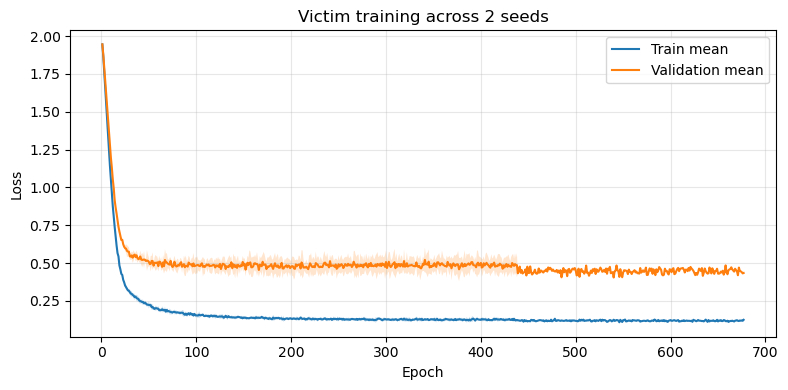

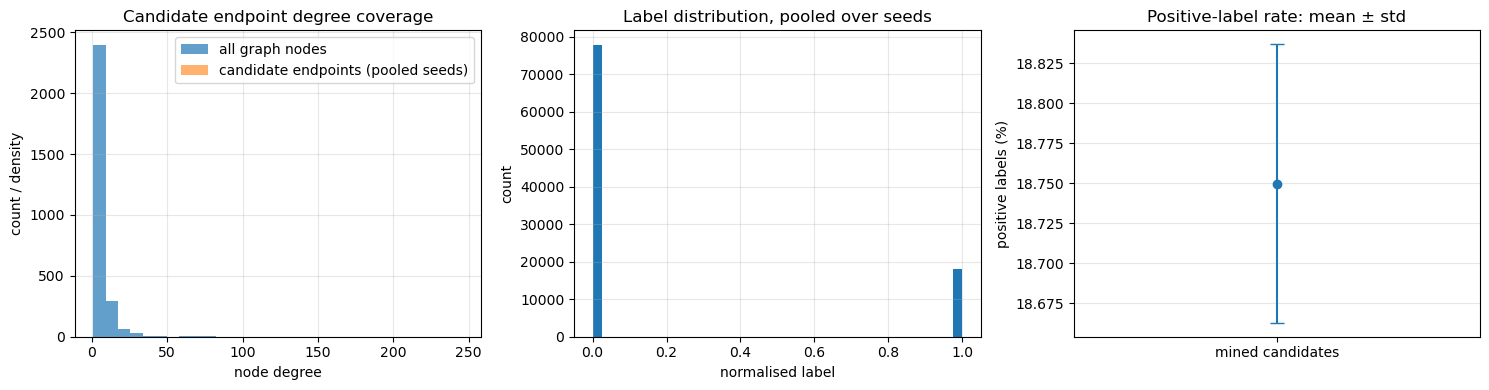

In [35]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    # ========================================================
    # Victim training and candidate/mining summaries
    # ========================================================
    victim_rows = []
    trace_rows = []
    candidate_rows = []
    mining_rows = []
    all_degrees = None
    candidate_degree_arrays = []
    pooled_labels = []

    for bundle in seed_bundles:
        seed = int(bundle["seed"])
        sections = bundle["sections"]
        victim = sections.get("victim", {})
        candidates = sections.get("candidates", {})
        mining = sections.get("mining", {})

        if victim:
            victim_rows.append({
                "seed": seed,
                "clean_accuracy": victim["clean_accuracy"],
            })
            n_epochs = max(
                len(victim.get("trace_train", [])),
                len(victim.get("trace_val", [])),
            )
            for epoch in range(n_epochs):
                trace_rows.append({
                    "seed": seed,
                    "epoch": epoch + 1,
                    "train_loss": (
                        victim["trace_train"][epoch]
                        if epoch < len(victim.get("trace_train", [])) else np.nan
                    ),
                    "val_loss": (
                        victim["trace_val"][epoch]
                        if epoch < len(victim.get("trace_val", [])) else np.nan
                    ),
                })

        if candidates:
            candidate_rows.append({
                "seed": seed,
                **{k: candidates[k] for k in (
                    "n_candidates", "n_prbcd", "n_random", "prbcd_fraction",
                    "n_additions", "n_removals"
                )},
            })
            if all_degrees is None:
                all_degrees = np.asarray(candidates["all_node_degrees"], dtype=float)
            candidate_degree_arrays.append(
                np.asarray(candidates["candidate_node_degrees"], dtype=float)
            )

        if mining:
            labels_seed = np.asarray(mining["labels_norm"], dtype=float)
            pooled_labels.append(labels_seed)
            mining_rows.append({
                "seed": seed,
                "clean_accuracy": mining["clean_accuracy"],
                "positive_rate": mining["positive_rate"],
                "label_mean": float(labels_seed.mean()),
                "label_std": float(labels_seed.std(ddof=1)) if len(labels_seed) > 1 else 0.0,
            })

    victim_df = pd.DataFrame(victim_rows)
    candidate_summary_df = pd.DataFrame(candidate_rows)
    mining_summary_df = pd.DataFrame(mining_rows)

    clean_mean, clean_std = mean_std(victim_df["clean_accuracy"])
    print(f"Clean test accuracy: {clean_mean:.4f} ± {clean_std:.4f}")

    print("\nCandidate pool statistics across seeds:")
    candidate_aggregate = candidate_summary_df.drop(columns="seed").agg(["mean", sample_std]).T
    candidate_aggregate.columns = ["mean", "std"]
    display(candidate_aggregate)
    candidate_aggregate.to_csv(
        MULTI_SEED_AGGREGATE_DIR / "candidate_pool_mean_std.csv"
    )

    print("\nMining statistics across seeds:")
    mining_aggregate = mining_summary_df.drop(columns="seed").agg(["mean", sample_std]).T
    mining_aggregate.columns = ["mean", "std"]
    display(mining_aggregate)
    mining_aggregate.to_csv(
        MULTI_SEED_AGGREGATE_DIR / "mining_mean_std.csv"
    )

    trace_df = pd.DataFrame(trace_rows)
    trace_summary = (
        trace_df.groupby("epoch", as_index=False)
        .agg(
            train_mean=("train_loss", "mean"),
            train_std=("train_loss", sample_std),
            val_mean=("val_loss", "mean"),
            val_std=("val_loss", sample_std),
            n_seeds=("seed", "nunique"),
        )
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    for prefix, label in (("train", "Train"), ("val", "Validation")):
        x = trace_summary["epoch"].to_numpy()
        mean = trace_summary[f"{prefix}_mean"].to_numpy()
        std = trace_summary[f"{prefix}_std"].fillna(0).to_numpy()
        ax.plot(x, mean, label=f"{label} mean")
        ax.fill_between(x, mean - std, mean + std, alpha=0.2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Victim training across {len(completed_seeds)} seeds")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(MULTI_SEED_AGGREGATE_DIR / "victim_training_mean_std.png", dpi=250)
    plt.show()

    pooled_labels_np = np.concatenate(pooled_labels) if pooled_labels else np.array([])
    pooled_candidate_degrees = (
        np.concatenate(candidate_degree_arrays)
        if candidate_degree_arrays else np.array([])
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if all_degrees is not None:
        axes[0].hist(all_degrees, bins=30, alpha=0.7, label="all graph nodes")
    if pooled_candidate_degrees.size:
        axes[0].hist(
            pooled_candidate_degrees,
            bins=30,
            alpha=0.6,
            density=True,
            label="candidate endpoints (pooled seeds)",
        )
    axes[0].set_xlabel("node degree")
    axes[0].set_ylabel("count / density")
    axes[0].set_title("Candidate endpoint degree coverage")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if pooled_labels_np.size:
        axes[1].hist(pooled_labels_np, bins=40)
    axes[1].set_xlabel("normalised label")
    axes[1].set_ylabel("count")
    axes[1].set_title("Label distribution, pooled over seeds")
    axes[1].grid(True, alpha=0.3)

    if not mining_summary_df.empty:
        axes[2].errorbar(
            [0],
            [100 * mining_summary_df["positive_rate"].mean()],
            yerr=[100 * sample_std(mining_summary_df["positive_rate"])],
            marker="o",
            capsize=5,
        )
    axes[2].set_xlim(-1, 1)
    axes[2].set_xticks([0])
    axes[2].set_xticklabels(["mined candidates"])
    axes[2].set_ylabel("positive labels (%)")
    axes[2].set_title("Positive-label rate: mean ± std")
    axes[2].grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    fig.savefig(MULTI_SEED_AGGREGATE_DIR / "candidate_and_label_stats_mean_std.png", dpi=250)
    plt.show()

,attack,k,accuracy_mean,accuracy_std,n_seeds
0,random candidates,0,0.859431,0.004194,2
1,random candidates,10,0.856465,0.001678,2
2,random candidates,20,0.855872,0.000839,2
3,random candidates,30,0.854686,0.000839,2
4,random candidates,40,0.852906,0.005033,2
5,random candidates,50,0.852906,0.005033,2
6,random candidates,60,0.847568,0.000839,2
7,random candidates,70,0.851720,0.001678,2
8,random candidates,80,0.842823,0.007549,2
9,random candidates,90,0.845789,0.003355,2


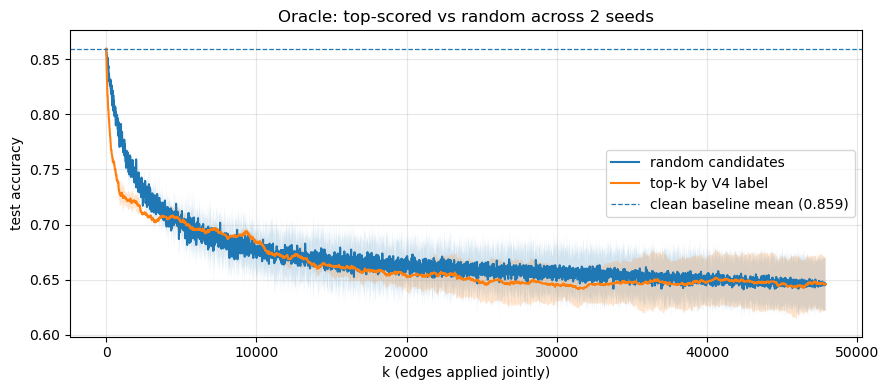

In [36]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    # ========================================================
    # Oracle check: top-scored labels versus random candidates
    # ========================================================
    oracle_all = records_from("oracle", "records")
    if not oracle_all.empty:
        oracle_summary = (
            oracle_all.groupby(["attack", "k"], as_index=False)
            .agg(
                accuracy_mean=("test_accuracy", "mean"),
                accuracy_std=("test_accuracy", sample_std),
                n_seeds=("master_seed", "nunique"),
            )
        )
        display(oracle_summary.head(20))
        oracle_summary.to_csv(
            MULTI_SEED_AGGREGATE_DIR / "oracle_curve_mean_std.csv",
            index=False,
        )

        fig, ax = plt.subplots(figsize=(9, 4))
        for attack, group in oracle_summary.groupby("attack"):
            group = group.sort_values("k")
            x = group["k"].to_numpy()
            mean = group["accuracy_mean"].to_numpy()
            std = group["accuracy_std"].fillna(0).to_numpy()
            ax.plot(x, mean, label=attack)
            ax.fill_between(x, mean - std, mean + std, alpha=0.2)
        ax.axhline(
            victim_df["clean_accuracy"].mean(),
            linestyle="--",
            linewidth=0.9,
            label=(
                f"clean baseline mean "
                f"({victim_df['clean_accuracy'].mean():.3f})"
            ),
        )
        ax.set_xlabel("k (edges applied jointly)")
        ax.set_ylabel("test accuracy")
        ax.set_title(
            f"Oracle: top-scored vs random across {len(completed_seeds)} seeds"
        )
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(MULTI_SEED_AGGREGATE_DIR / "oracle_mean_std.png", dpi=250)
        plt.show()
    else:
        print("No oracle records were exported.")

Held-out selector metrics:


,mean,std
test_auc,0.943167,0.000478
test_average_precision,0.834985,0.004873
test_correlation,0.743748,0.007213
test_positive_rate,0.187543,0.000886
best_epoch,524.500000,33.234019
stopped_at,539.500000,33.234019


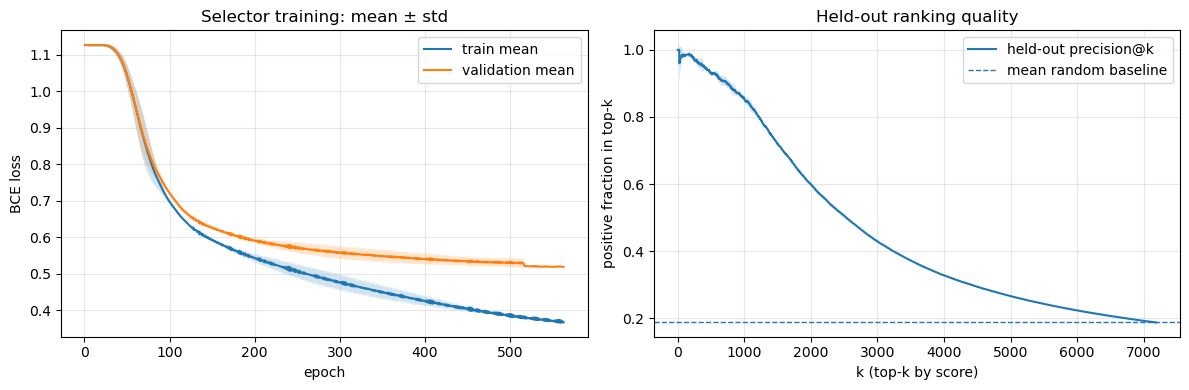

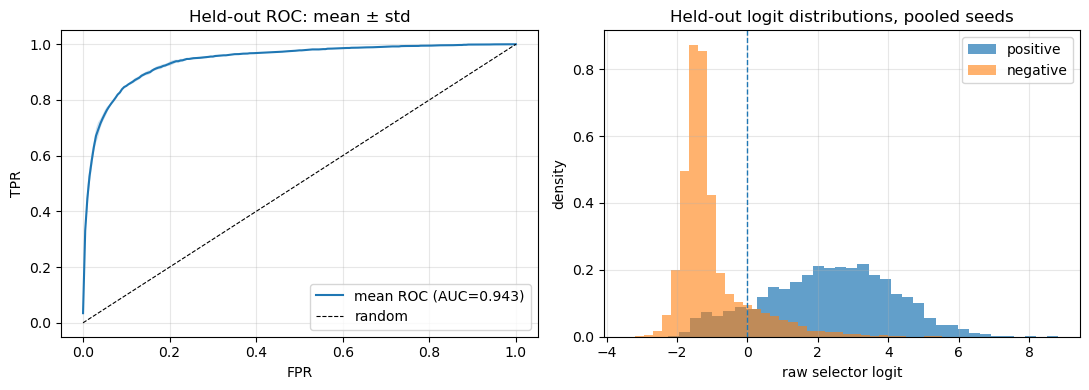

In [37]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    # ========================================================
    # Selector training and held-out ranking quality
    # ========================================================
    scorer_metric_rows = []
    scorer_history_rows = []
    precision_rows = []
    roc_rows = []
    positive_logits = []
    negative_logits = []

    fpr_grid = np.linspace(0.0, 1.0, 201)

    for bundle in seed_bundles:
        seed = int(bundle["seed"])
        scorer = bundle["sections"].get("scorer", {})
        if not scorer:
            continue
        history = scorer["history"]
        test = scorer["test"]

        scorer_metric_rows.append({
            "seed": seed,
            "test_auc": test["auc"],
            "test_average_precision": test["average_precision"],
            "test_correlation": test["correlation"],
            "test_positive_rate": test["positive_rate"],
            "best_epoch": history.get("best_epoch"),
            "stopped_at": history.get("stopped_at"),
        })

        train_losses = np.asarray(history.get("train_losses", []), dtype=float)
        val_losses = np.asarray(history.get("val_losses", []), dtype=float)
        for epoch in range(max(len(train_losses), len(val_losses))):
            scorer_history_rows.append({
                "seed": seed,
                "epoch": epoch + 1,
                "train_loss": train_losses[epoch] if epoch < len(train_losses) else np.nan,
                "val_loss": val_losses[epoch] if epoch < len(val_losses) else np.nan,
            })

        precision = np.asarray(test["precision_at_k"], dtype=float)
        for k, value in enumerate(precision, start=1):
            precision_rows.append({"seed": seed, "k": k, "precision": value})

        labels_test = np.asarray(test["labels"], dtype=int)
        logits_test = np.asarray(test["logits"], dtype=float)
        positive_logits.append(logits_test[labels_test == 1])
        negative_logits.append(logits_test[labels_test == 0])

        fpr = np.asarray(test["fpr"], dtype=float)
        tpr = np.asarray(test["tpr"], dtype=float)
        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        for x, y in zip(fpr_grid, tpr_interp):
            roc_rows.append({"seed": seed, "fpr": x, "tpr": y})

    scorer_metrics_df = pd.DataFrame(scorer_metric_rows)
    print("Held-out selector metrics:")
    scorer_metrics_summary = scorer_metrics_df.drop(columns="seed").agg(["mean", sample_std]).T
    scorer_metrics_summary.columns = ["mean", "std"]
    display(scorer_metrics_summary)
    scorer_metrics_summary.to_csv(
        MULTI_SEED_AGGREGATE_DIR / "selector_test_metrics_mean_std.csv"
    )

    history_df = pd.DataFrame(scorer_history_rows)
    history_summary = (
        history_df.groupby("epoch", as_index=False)
        .agg(
            train_mean=("train_loss", "mean"),
            train_std=("train_loss", sample_std),
            val_mean=("val_loss", "mean"),
            val_std=("val_loss", sample_std),
            n_seeds=("seed", "nunique"),
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for prefix, label in (("train", "train"), ("val", "validation")):
        x = history_summary["epoch"].to_numpy()
        mean = history_summary[f"{prefix}_mean"].to_numpy()
        std = history_summary[f"{prefix}_std"].fillna(0).to_numpy()
        axes[0].plot(x, mean, label=f"{label} mean")
        axes[0].fill_between(x, mean - std, mean + std, alpha=0.2)
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("BCE loss")
    axes[0].set_title("Selector training: mean ± std")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    precision_df = pd.DataFrame(precision_rows)
    precision_summary = (
        precision_df.groupby("k", as_index=False)
        .agg(
            precision_mean=("precision", "mean"),
            precision_std=("precision", sample_std),
            n_seeds=("seed", "nunique"),
        )
    )
    x = precision_summary["k"].to_numpy()
    mean = precision_summary["precision_mean"].to_numpy()
    std = precision_summary["precision_std"].fillna(0).to_numpy()
    axes[1].plot(x, mean, label="held-out precision@k")
    axes[1].fill_between(x, mean - std, mean + std, alpha=0.2)
    axes[1].axhline(
        scorer_metrics_df["test_positive_rate"].mean(),
        linestyle="--",
        linewidth=1,
        label="mean random baseline",
    )
    axes[1].set_xlabel("k (top-k by score)")
    axes[1].set_ylabel("positive fraction in top-k")
    axes[1].set_title("Held-out ranking quality")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(MULTI_SEED_AGGREGATE_DIR / "selector_training_and_precision_mean_std.png", dpi=250)
    plt.show()

    roc_df = pd.DataFrame(roc_rows)
    roc_summary = (
        roc_df.groupby("fpr", as_index=False)
        .agg(
            tpr_mean=("tpr", "mean"),
            tpr_std=("tpr", sample_std),
        )
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    x = roc_summary["fpr"].to_numpy()
    mean = roc_summary["tpr_mean"].to_numpy()
    std = roc_summary["tpr_std"].fillna(0).to_numpy()
    axes[0].plot(x, mean, label=f"mean ROC (AUC={scorer_metrics_df['test_auc'].mean():.3f})")
    axes[0].fill_between(x, np.clip(mean - std, 0, 1), np.clip(mean + std, 0, 1), alpha=0.2)
    axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random")
    axes[0].set_xlabel("FPR")
    axes[0].set_ylabel("TPR")
    axes[0].set_title("Held-out ROC: mean ± std")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    pos = np.concatenate(positive_logits) if positive_logits else np.array([])
    neg = np.concatenate(negative_logits) if negative_logits else np.array([])
    if len(pos):
        axes[1].hist(pos, bins=35, alpha=0.7, density=True, label="positive")
    if len(neg):
        axes[1].hist(neg, bins=35, alpha=0.6, density=True, label="negative")
    axes[1].axvline(0, linestyle="--", linewidth=1)
    axes[1].set_xlabel("raw selector logit")
    axes[1].set_ylabel("density")
    axes[1].set_title("Held-out logit distributions, pooled seeds")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(MULTI_SEED_AGGREGATE_DIR / "selector_roc_and_logits_mean_std.png", dpi=250)
    plt.show()

Per-node selector separation across seeds:


,mean,std
mean_score_gap,3.399398,0.105338
median_score_gap,3.492846,0.105642
positive_gap_fraction,0.996331,0.001420
nodes_with_both,2597.500000,41.719300


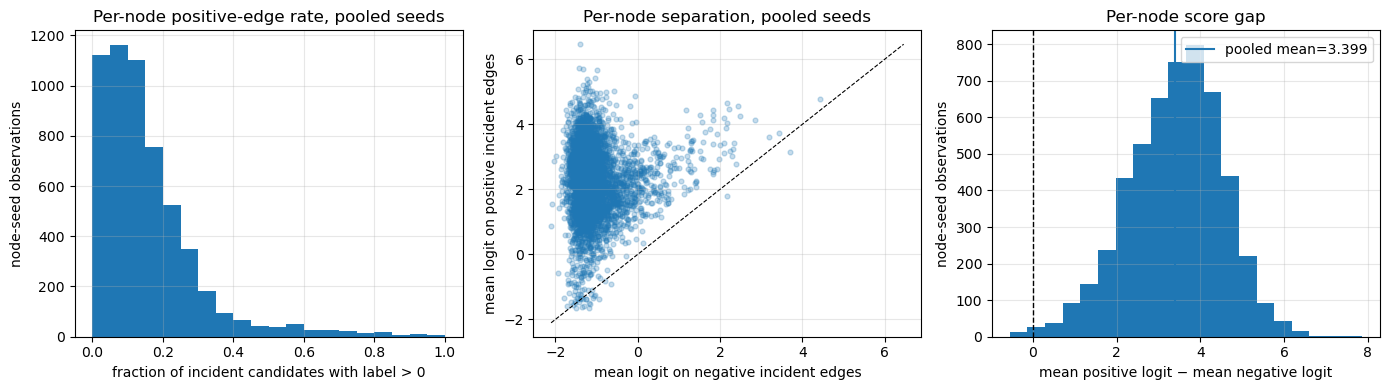

In [38]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    # ========================================================
    # Per-node selector analysis, pooled across seeds
    # ========================================================
    per_node_all = records_from("per_node", "records")
    if not per_node_all.empty:
        for column in (
            "scored_rate", "mean_score_pos", "mean_score_neg", "degree"
        ):
            per_node_all[column] = pd.to_numeric(
                per_node_all[column], errors="coerce"
            )

        has_both = per_node_all.dropna(
            subset=["mean_score_pos", "mean_score_neg"]
        ).copy()
        has_both["score_gap"] = (
            has_both["mean_score_pos"] - has_both["mean_score_neg"]
        )

        per_seed_node_summary = (
            has_both.groupby("master_seed", as_index=False)
            .agg(
                mean_score_gap=("score_gap", "mean"),
                median_score_gap=("score_gap", "median"),
                positive_gap_fraction=("score_gap", lambda x: float((x > 0).mean())),
                nodes_with_both=("node", "count"),
            )
        )
        print("Per-node selector separation across seeds:")
        node_summary = per_seed_node_summary.drop(columns="master_seed").agg(
            ["mean", sample_std]
        ).T
        node_summary.columns = ["mean", "std"]
        display(node_summary)
        node_summary.to_csv(
            MULTI_SEED_AGGREGATE_DIR / "per_node_selector_mean_std.csv"
        )

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].hist(
            per_node_all["scored_rate"].dropna(),
            bins=20,
        )
        axes[0].set_xlabel("fraction of incident candidates with label > 0")
        axes[0].set_ylabel("node-seed observations")
        axes[0].set_title("Per-node positive-edge rate, pooled seeds")
        axes[0].grid(True, alpha=0.3)

        axes[1].scatter(
            has_both["mean_score_neg"],
            has_both["mean_score_pos"],
            alpha=0.25,
            s=12,
        )
        if not has_both.empty:
            lo = min(
                has_both["mean_score_neg"].min(),
                has_both["mean_score_pos"].min(),
            )
            hi = max(
                has_both["mean_score_neg"].max(),
                has_both["mean_score_pos"].max(),
            )
            axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=0.8)
        axes[1].set_xlabel("mean logit on negative incident edges")
        axes[1].set_ylabel("mean logit on positive incident edges")
        axes[1].set_title("Per-node separation, pooled seeds")
        axes[1].grid(True, alpha=0.3)

        axes[2].hist(has_both["score_gap"], bins=20)
        axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
        gap_mean, gap_std = mean_std(has_both["score_gap"])
        axes[2].axvline(
            gap_mean,
            linewidth=1.5,
            label=f"pooled mean={gap_mean:.3f}",
        )
        axes[2].set_xlabel("mean positive logit − mean negative logit")
        axes[2].set_ylabel("node-seed observations")
        axes[2].set_title("Per-node score gap")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        fig.tight_layout()
        fig.savefig(
            MULTI_SEED_AGGREGATE_DIR / "per_node_selector_pooled.png",
            dpi=250,
        )
        plt.show()
    else:
        print("No per-node selector records were exported.")

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


,k,lp_mean,lp_std,random_mean,random_seed_std,advantage_mean,advantage_std,n_seeds
0,0,0.859431,0.004194,0.859431,0.004194,0.000000,0.000000,2
1,10,0.854093,0.003355,0.859312,0.004194,0.005219,0.000839,2
2,20,0.852906,0.001678,0.859312,0.004026,0.006406,0.002349,2
3,30,0.850534,0.000000,0.859134,0.003439,0.008600,0.003439,2
4,40,0.849348,0.000000,0.859253,0.003104,0.009905,0.003104,2
5,50,0.846382,0.000839,0.859312,0.003020,0.012930,0.003858,2
6,60,0.845196,0.000839,0.859134,0.003775,0.013938,0.004613,2
7,70,0.843416,0.003355,0.858600,0.003020,0.015184,0.006375,2
8,80,0.842230,0.005033,0.857829,0.002600,0.015599,0.007633,2
9,90,0.839265,0.002516,0.857888,0.002349,0.018624,0.004865,2


,k,lp_mean,lp_std,random_mean,random_seed_std,advantage_mean,advantage_std,n_seeds
4770,47700,0.752076,0.028519,0.752491,0.030281,4.151732e-04,0.001761,2
4771,47710,0.752076,0.028519,0.752432,0.030197,3.558606e-04,0.001678,2
4772,47720,0.752076,0.028519,0.752432,0.030197,3.558606e-04,0.001678,2
4773,47730,0.752076,0.028519,0.752432,0.030197,3.558606e-04,0.001678,2
4774,47740,0.752076,0.028519,0.752491,0.030113,4.151732e-04,0.001594,2
4775,47750,0.752076,0.028519,0.752491,0.030113,4.151732e-04,0.001594,2
4776,47760,0.752076,0.028519,0.752491,0.030448,4.151672e-04,0.001929,2
4777,47770,0.752076,0.028519,0.752432,0.030364,3.558546e-04,0.001845,2
4778,47780,0.752076,0.028519,0.752372,0.030281,2.965420e-04,0.001761,2
4779,47790,0.752669,0.029358,0.752432,0.030364,-2.372712e-04,0.001007,2


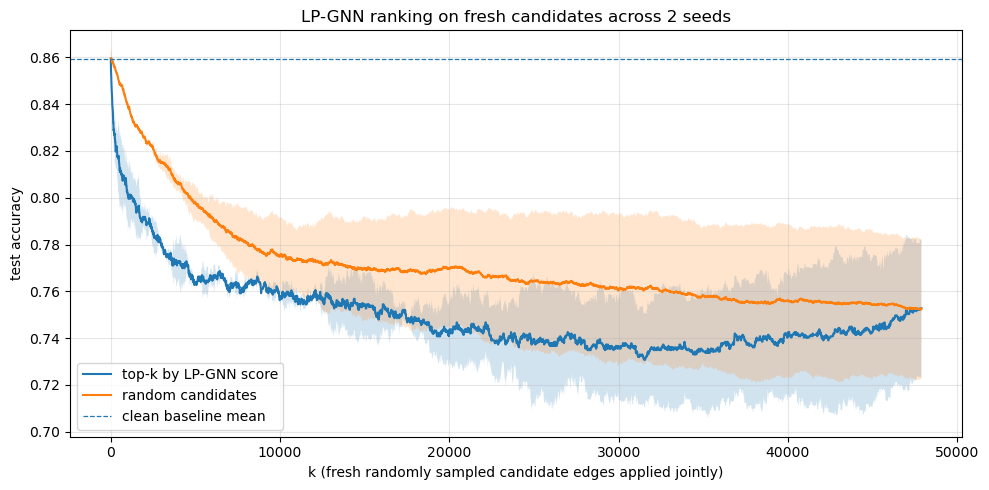

In [39]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    # ========================================================
    # Fresh all-pairs candidate ranking test
    # ========================================================
    fresh_all = records_from("fresh_selector_oracle", "analysis_records")
    if not fresh_all.empty:
        fresh_summary = (
            fresh_all.groupby("k", as_index=False)
            .agg(
                lp_mean=("lp_gnn_accuracy", "mean"),
                lp_std=("lp_gnn_accuracy", sample_std),
                random_mean=("random_mean", "mean"),
                random_seed_std=("random_mean", sample_std),
                advantage_mean=("lp_gnn_advantage", "mean"),
                advantage_std=("lp_gnn_advantage", sample_std),
                n_seeds=("master_seed", "nunique"),
            )
        )
        display(fresh_summary.head(20))
        display(fresh_summary.tail(20))
        fresh_summary.to_csv(
            MULTI_SEED_AGGREGATE_DIR / "fresh_selector_oracle_mean_std.csv",
            index=False,
        )

        fig, ax = plt.subplots(figsize=(10, 5))
        x = fresh_summary["k"].to_numpy()
        for mean_col, std_col, label in (
            ("lp_mean", "lp_std", "top-k by LP-GNN score"),
            ("random_mean", "random_seed_std", "random candidates"),
        ):
            mean = fresh_summary[mean_col].to_numpy()
            std = fresh_summary[std_col].fillna(0).to_numpy()
            ax.plot(x, mean, label=label)
            ax.fill_between(x, mean - std, mean + std, alpha=0.2)
        ax.axhline(
            victim_df["clean_accuracy"].mean(),
            linestyle="--",
            linewidth=0.9,
            label="clean baseline mean",
        )
        ax.set_xlabel("k (fresh randomly sampled candidate edges applied jointly)")
        ax.set_ylabel("test accuracy")
        ax.set_title(
            f"LP-GNN ranking on fresh candidates across {len(completed_seeds)} seeds"
        )
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(MULTI_SEED_AGGREGATE_DIR / "fresh_selector_oracle_mean_std.png", dpi=250)
        plt.show()
    else:
        print("Fresh-candidate selector experiment was disabled or produced no records.")

Guided PRBCD final results:


,use_cert_label,final_accuracy_mean,final_accuracy_std,runtime_mean,runtime_std,n_seeds
1,accuracy_drop_selector_with_resampling__mode-o...,0.756324,0.003074,225.525332,17.167685,2
0,accuracy_drop_selector__mode-one_sample__drop-...,0.761660,0.001677,295.599493,121.192331,2
2,none,0.767194,0.000559,243.444275,47.974288,2


Accuracy improvement relative to standard PRBCD (percentage points):


,use_cert_label,improvement_vs_none_pp
1,accuracy_drop_selector_with_resampling__mode-o...,1.086956
0,accuracy_drop_selector__mode-one_sample__drop-...,0.553358
2,none,0.000000


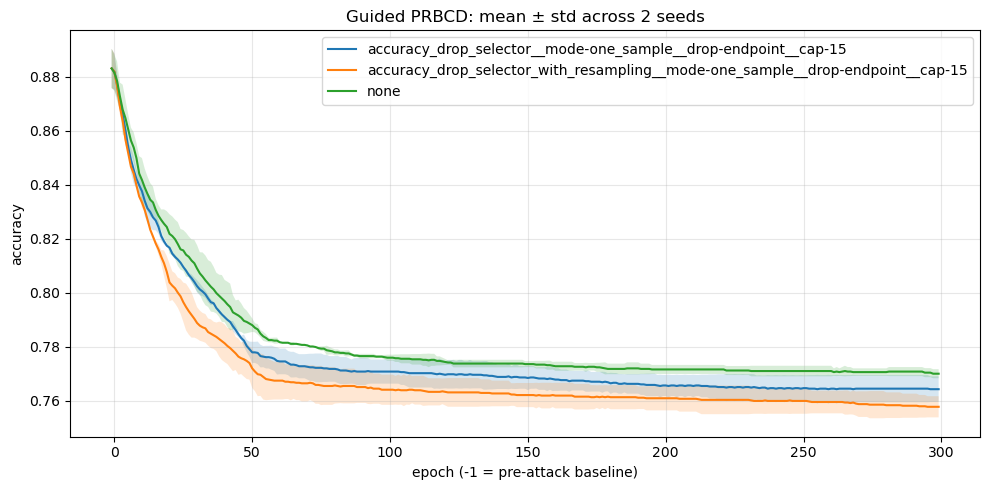

In [40]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    # ========================================================
    # Guided PRBCD end-to-end evaluation
    # ========================================================
    guided_summary_all = records_from("guided_prbcd", "summary_records")
    guided_epochs_all = records_from("guided_prbcd", "epoch_records")

    if not guided_summary_all.empty:
        guided_ok = guided_summary_all[
            guided_summary_all["status"].astype(str) == "ok"
        ].copy()
        guided_ok["accuracy"] = pd.to_numeric(guided_ok["accuracy"], errors="coerce")
        guided_ok["runtime_seconds"] = pd.to_numeric(
            guided_ok["runtime_seconds"], errors="coerce"
        )
        guided_final = (
            guided_ok.groupby("use_cert_label", as_index=False)
            .agg(
                final_accuracy_mean=("accuracy", "mean"),
                final_accuracy_std=("accuracy", sample_std),
                runtime_mean=("runtime_seconds", "mean"),
                runtime_std=("runtime_seconds", sample_std),
                n_seeds=("master_seed", "nunique"),
            )
            .sort_values("final_accuracy_mean")
        )
        print("Guided PRBCD final results:")
        display(guided_final)
        guided_final.to_csv(
            MULTI_SEED_AGGREGATE_DIR / "guided_prbcd_final_mean_std.csv",
            index=False,
        )

        baseline_rows = guided_final[
            guided_final["use_cert_label"].astype(str).eq("none")
        ]
        if not baseline_rows.empty:
            baseline_acc = float(baseline_rows.iloc[0]["final_accuracy_mean"])
            guided_final["improvement_vs_none_pp"] = (
                100 * (baseline_acc - guided_final["final_accuracy_mean"])
            )
            print("Accuracy improvement relative to standard PRBCD (percentage points):")
            display(guided_final[["use_cert_label", "improvement_vs_none_pp"]])

    if not guided_epochs_all.empty:
        guided_epochs_all["epoch_idx"] = pd.to_numeric(
            guided_epochs_all["epoch_idx"], errors="coerce"
        )
        guided_epochs_all["accuracy"] = pd.to_numeric(
            guided_epochs_all["accuracy"], errors="coerce"
        )
        guided_epoch_summary = (
            guided_epochs_all.dropna(subset=["epoch_idx", "accuracy"])
            .groupby(["use_cert_label", "epoch_idx"], as_index=False)
            .agg(
                accuracy_mean=("accuracy", "mean"),
                accuracy_std=("accuracy", sample_std),
                n_seeds=("master_seed", "nunique"),
            )
        )
        guided_epoch_summary.to_csv(
            MULTI_SEED_AGGREGATE_DIR / "guided_prbcd_epochs_mean_std.csv",
            index=False,
        )

        fig, ax = plt.subplots(figsize=(10, 5))
        for method, group in guided_epoch_summary.groupby("use_cert_label"):
            group = group.sort_values("epoch_idx")
            x = group["epoch_idx"].to_numpy()
            mean = group["accuracy_mean"].to_numpy()
            std = group["accuracy_std"].fillna(0).to_numpy()
            ax.plot(x, mean, label=str(method))
            ax.fill_between(x, mean - std, mean + std, alpha=0.18)
        ax.set_xlabel("epoch (-1 = pre-attack baseline)")
        ax.set_ylabel("accuracy")
        ax.set_title(
            f"Guided PRBCD: mean ± std across {len(completed_seeds)} seeds"
        )
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(MULTI_SEED_AGGREGATE_DIR / "guided_prbcd_epochs_mean_std.png", dpi=250)
        plt.show()
    else:
        print("Guided PRBCD experiment was disabled or produced no epoch records.")

,block_size,never_sampled_mean,never_sampled_std,absent_final_mean,absent_final_std,final_accuracy_mean,final_accuracy_std,n_seeds
0,1000,0.993617,0.003060,0.998723,0.000612,0.841897,0.001304,2
1,2000,0.987271,0.002287,0.994477,0.000650,0.821937,0.002329,2
2,4000,0.979200,0.001614,0.989392,0.001706,0.799012,0.000652,2
3,8000,0.942275,0.005485,0.991507,0.000077,0.783136,0.000559,2
4,16000,0.893839,0.000956,0.982154,0.002563,0.776680,0.000745,2


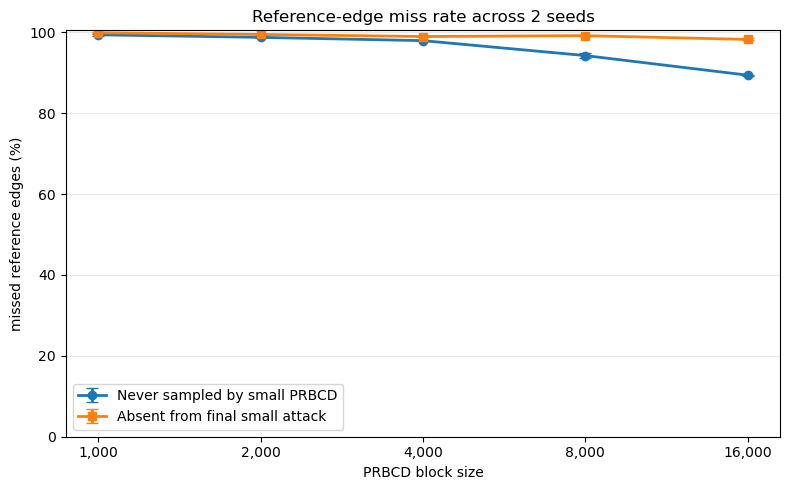

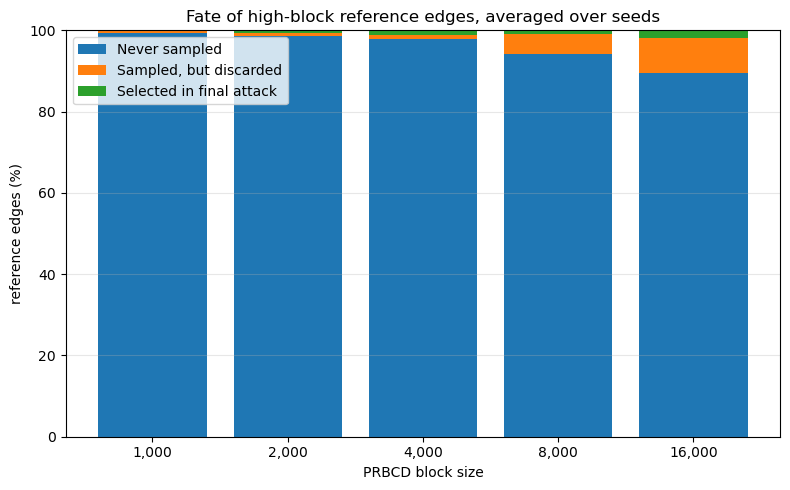

In [41]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    # ========================================================
    # RQ1: search-space coverage across victim/attack seeds
    # ========================================================
    rq1_all = records_from("rq1", "summary_records")
    rq1_status_all = records_from("rq1", "edge_status_records")

    if not rq1_all.empty:
        rq1_all["never_sampled_rate"] = 1.0 - pd.to_numeric(
            rq1_all["reference_discovery_recall"], errors="coerce"
        )
        rq1_all["absent_from_final_rate"] = 1.0 - pd.to_numeric(
            rq1_all["final_reference_recall"], errors="coerce"
        )

        # First average the repeated small-block attacks within each master seed.
        rq1_seed_means = (
            rq1_all.groupby(["master_seed", "block_size"], as_index=False)
            .agg(
                never_sampled_rate=("never_sampled_rate", "mean"),
                absent_from_final_rate=("absent_from_final_rate", "mean"),
                final_accuracy=("final_accuracy", "mean"),
                runtime_seconds=("runtime_seconds", "mean"),
                repeats=("repeat", "count"),
            )
        )

        rq1_summary = (
            rq1_seed_means.groupby("block_size", as_index=False)
            .agg(
                never_sampled_mean=("never_sampled_rate", "mean"),
                never_sampled_std=("never_sampled_rate", sample_std),
                absent_final_mean=("absent_from_final_rate", "mean"),
                absent_final_std=("absent_from_final_rate", sample_std),
                final_accuracy_mean=("final_accuracy", "mean"),
                final_accuracy_std=("final_accuracy", sample_std),
                n_seeds=("master_seed", "nunique"),
            )
            .sort_values("block_size")
        )
        display(rq1_summary)
        rq1_summary.to_csv(
            MULTI_SEED_AGGREGATE_DIR / "rq1_miss_rates_mean_std.csv",
            index=False,
        )

        fig, ax = plt.subplots(figsize=(8, 5))
        for mean_col, std_col, marker, label in (
            (
                "never_sampled_mean", "never_sampled_std", "o",
                "Never sampled by small PRBCD",
            ),
            (
                "absent_final_mean", "absent_final_std", "s",
                "Absent from final small attack",
            ),
        ):
            ax.errorbar(
                rq1_summary["block_size"],
                100 * rq1_summary[mean_col],
                yerr=100 * rq1_summary[std_col].fillna(0),
                marker=marker,
                capsize=4,
                linewidth=2,
                label=label,
            )
        ax.set_xscale("log", base=2)
        ax.set_xticks(rq1_summary["block_size"])
        ax.set_xticklabels([f"{int(v):,}" for v in rq1_summary["block_size"]])
        ax.set_xlabel("PRBCD block size")
        ax.set_ylabel("missed reference edges (%)")
        ax.set_title(
            f"Reference-edge miss rate across {len(completed_seeds)} seeds"
        )
        ax.set_ylim(bottom=0)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(MULTI_SEED_AGGREGATE_DIR / "rq1_miss_rate_mean_std.png", dpi=250)
        plt.show()

    if not rq1_status_all.empty:
        status_counts = (
            rq1_status_all.groupby(
                ["master_seed", "block_size", "repeat", "status"],
                as_index=False,
            ).size()
        )
        totals = status_counts.groupby(
            ["master_seed", "block_size", "repeat"]
        )["size"].transform("sum")
        status_counts["proportion"] = status_counts["size"] / totals

        # Average repeats within seed, then average seeds.
        status_seed = (
            status_counts.groupby(
                ["master_seed", "block_size", "status"], as_index=False
            )["proportion"].mean()
        )
        status_summary = (
            status_seed.groupby(["block_size", "status"], as_index=False)
            .agg(
                proportion_mean=("proportion", "mean"),
                proportion_std=("proportion", sample_std),
            )
        )
        status_order = [
            "never_sampled_by_small_run",
            "sampled_but_not_final",
            "found_in_small_final",
        ]
        status_labels = {
            "never_sampled_by_small_run": "Never sampled",
            "sampled_but_not_final": "Sampled, but discarded",
            "found_in_small_final": "Selected in final attack",
        }
        pivot = (
            status_summary.pivot(
                index="block_size", columns="status", values="proportion_mean"
            )
            .reindex(columns=status_order)
            .fillna(0.0)
            .sort_index()
        )
        fig, ax = plt.subplots(figsize=(8, 5))
        bottom = np.zeros(len(pivot))
        for status in status_order:
            values = 100 * pivot[status].to_numpy()
            ax.bar(
                [f"{int(v):,}" for v in pivot.index],
                values,
                bottom=bottom,
                label=status_labels[status],
            )
            bottom += values
        ax.set_xlabel("PRBCD block size")
        ax.set_ylabel("reference edges (%)")
        ax.set_title("Fate of high-block reference edges, averaged over seeds")
        ax.set_ylim(0, 100)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(MULTI_SEED_AGGREGATE_DIR / "rq1_edge_status_mean.png", dpi=250)
        plt.show()
    else:
        print("RQ1 experiment was disabled or produced no records.")

In [42]:
if RUN_MODE == "multi_seed" and not MULTI_SEED_WORKER:
    print("\nMulti-seed aggregation complete.")
    print("Numerical summaries and figures:", MULTI_SEED_AGGREGATE_DIR)
    print("Per-seed bundles:", MULTI_SEED_BUNDLE_DIR)
    print("Fully executed per-seed notebooks:", MULTI_SEED_EXECUTED_DIR)


Multi-seed aggregation complete.
Numerical summaries and figures: E:\Masterarbeit\AttackerGNN\notebooks\extendedPlotting\multiseed\20260704_002358\aggregate
Per-seed bundles: E:\Masterarbeit\AttackerGNN\notebooks\extendedPlotting\multiseed\20260704_002358\bundles
Fully executed per-seed notebooks: E:\Masterarbeit\AttackerGNN\notebooks\extendedPlotting\multiseed\20260704_002358\executed_notebooks
